# Phase 7 - Explainability: SHAP + Permutation Importance + Attention Fusion + Granger Causality

## Overview

Phase 7 makes every prediction produced by Phase 5 and Phase 6 **fully explainable**. It answers the question *why* did the model predict this?

| What | How |
|---|---|
| SHAP on XGBoost regime classifier | `TreeExplainer` - fast, exact, per-class SHAP values |
| SHAP by regime | Per-regime SHAP breakdown: which features drive LOW vs ELEVATED vs CRISIS predictions differently |
| SHAP interaction heatmap | Pairwise feature interactions for the CRISIS class |
| SHAP stability check | Ranking consistency across two random subsets - confirms explanations are reliable |
| LSTM permutation importance | Model-agnostic feature attribution - used in place of GradientExplainer/DeepExplainer which both fail on the custom Attention layer |
| Attention × importance fusion | Joint heatmap combining LSTM attention (which *timesteps* matter) with permutation importance (which *features* matter) |
| Attention profiles by regime | How the LSTM attention profile changes between LOW, ELEVATED, and CRISIS predictions |
| Granger causality | Revised tests with `sentiment_source` exclusion flag built in Phase 3 |
| `get_top_drivers()` | Production function - per-horizon, per-regime driver dict consumed by Phase 8 bulletin |


## Cell 1 - Environment Setup

In [1]:
import os, sys, json, warnings, random
warnings.filterwarnings('ignore')

PROJECT_ROOT = r'C:\Users\sabin\genai-market'

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy  as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import xgboost as xgb
import shap

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device('cpu')

sns.set_theme(
    style='darkgrid', palette='muted', font_scale=1.05,
    rc={
        'figure.dpi'          : 130,
        'axes.spines.top'     : False,
        'axes.spines.right'   : False,
        'axes.titleweight'    : 'bold',
        'axes.titlesize'      : 11,
        'figure.facecolor'    : 'white',
    }
)
REGIME_COLORS = {'LOW': '#2ecc71', 'ELEVATED': '#f39c12', 'CRISIS': '#e74c3c'}

print(f'Project root : {PROJECT_ROOT}')
print(f'Device       : {DEVICE}')
print(f'PyTorch      : {torch.__version__}')
print(f'NumPy        : {np.__version__}')
print(f'Pandas       : {pd.__version__}')
print(f'XGBoost      : {xgb.__version__}')
print(f'SHAP         : {shap.__version__}')

Project root : C:\Users\sabin\genai-market
Device       : cpu
PyTorch      : 2.10.0+cpu
NumPy        : 2.2.5
Pandas       : 2.3.3
XGBoost      : 2.1.1
SHAP         : 0.49.1


## Cell 2 - Constants & Paths

In [16]:
#  Split boundaries 
TRAIN_END = '2018-12-31'
VAL_END   = '2021-12-31'

#  LSTM architecture 
SEQUENCE_LENGTH = 60
HORIZONS        = [1, 5, 10]
HORIZON_NAMES   = ['t+1 (next day)', 't+5 (next week)', 't+10 (next fortnight)']
HIDDEN_SIZE     = 128
NUM_LAYERS      = 2
DROPOUT         = 0.2
BATCH_SIZE      = 32

FEATURE_COLS = [
    'vix_lag1', 'vix_lag5', 'vix_lag21',
    'vix_roll_mean5', 'vix_roll_std21',
    'fedfunds', 'cpi', 'unrate', 'gs10', 'indpro', 'm2sl',
    'sentiment'
]
N_FEATURES   = len(FEATURE_COLS)
REGIME_ORDER = ['LOW', 'ELEVATED', 'CRISIS']

#  Phase 7 specific
GRANGER_LAGS     = [1, 5, 10, 21]   # causal lags to test
SHAP_BACKGROUND  = 300              # GradientExplainer background samples
STABILITY_SPLITS  = 2               # number of subsets for stability check
STABILITY_FRAC   = 0.6              # fraction of test set per subset

#  File paths
PATHS = {
    'master_df'   : os.path.join(PROJECT_ROOT, 'data', 'processed', 'master_df.csv'),
    'lstm_weights': os.path.join(PROJECT_ROOT, 'models', 'lstm_model.pt'),
    'lstm_config' : os.path.join(PROJECT_ROOT, 'models', 'lstm_config.json'),
    'regime_clf'  : os.path.join(PROJECT_ROOT, 'models', 'regime_classifier.pkl'),
    'results'     : os.path.join(PROJECT_ROOT, 'models', 'results_table.csv'),
    'explainability': os.path.join(PROJECT_ROOT, 'models', 'explainability_cache.pkl'),
    'figures'     : os.path.join(PROJECT_ROOT, 'figures'),
    'src'         : os.path.join(PROJECT_ROOT, 'src'),
}
os.makedirs(PATHS['figures'], exist_ok=True)
os.makedirs(PATHS['src'],     exist_ok=True)

print(f'N features   : {N_FEATURES}')
print(f'Feature cols : {FEATURE_COLS}')
print(f'Granger lags : {GRANGER_LAGS}')
print(f'SHAP bg size : {SHAP_BACKGROUND}')

N features   : 12
Feature cols : ['vix_lag1', 'vix_lag5', 'vix_lag21', 'vix_roll_mean5', 'vix_roll_std21', 'fedfunds', 'cpi', 'unrate', 'gs10', 'indpro', 'm2sl', 'sentiment']
Granger lags : [1, 5, 10, 21]
SHAP bg size : 300


## Cell 3 - Load Data & Rebuild Splits

In [3]:
df = pd.read_csv(PATHS['master_df'], index_col=0, parse_dates=True)

train_df = df[df.index <= TRAIN_END].copy()
val_df   = df[(df.index > TRAIN_END) & (df.index <= VAL_END)].copy()
test_df  = df[df.index > VAL_END].copy()

print(f'master_df  : {df.shape}  |  {df.index[0].date()} -> {df.index[-1].date()}')
print(f'Train      : {train_df.shape}')
print(f'Val        : {val_df.shape}')
print(f'Test       : {test_df.shape}')
print(f'Columns    : {list(df.columns)}')

#  Sentiment coverage sanity check — used later for Granger exclusion
finbert_days = (df['sentiment_source'] == 'finbert').sum()
neutral_days = (df['sentiment_source'] == 'default_neutral').sum()
print(f'\nSentiment coverage: {finbert_days} FinBERT-scored | {neutral_days} default-neutral (pre-2009)')

master_df  : (6577, 17)  |  2000-02-02 -> 2026-03-27
Train      : (4758, 17)
Val        : (757, 17)
Test       : (1062, 17)
Columns    : ['vix', 'vix_log', 'vix_return', 'vix_lag1', 'vix_lag5', 'vix_lag21', 'vix_roll_mean5', 'vix_roll_std21', 'regime_label', 'fedfunds', 'cpi', 'unrate', 'gs10', 'indpro', 'm2sl', 'sentiment', 'sentiment_source']

Sentiment coverage: 2776 FinBERT-scored | 3801 default-neutral (pre-2009)


## Cell 4 - Reload LSTM & XGBoost Models

In [4]:
# Model class definitions (verbatim from src/modeling.py) 
class VIXDataset(Dataset):
    def __init__(self, dataframe, feature_cols, target_col='vix_log',
                 sequence_length=60, horizons=None):
        if horizons is None:
            horizons = [5]
        self.seq_len  = sequence_length
        self.horizons = horizons
        self.max_h    = max(horizons)
        self.X        = dataframe[feature_cols].values.astype(np.float32)
        self.target   = dataframe[target_col].values.astype(np.float32)
        self.indices  = list(range(sequence_length, len(dataframe) - self.max_h))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        x   = self.X[idx - self.seq_len : idx]
        y   = np.array([self.target[idx + h] for h in self.horizons], dtype=np.float32)
        return torch.tensor(x), torch.tensor(y), idx


class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn    = nn.Linear(hidden_size, hidden_size)
        self.context = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, lstm_output):
        energy  = self.context(torch.tanh(self.attn(lstm_output)))
        weights = torch.softmax(energy, dim=1)
        context = (weights * lstm_output).sum(dim=1)
        return context, weights.squeeze(-1)


class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2,
                 dropout=0.2, n_horizons=3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.attention = Attention(hidden_size)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_size, n_horizons)

    def forward(self, x):
        lstm_out, _     = self.lstm(x)
        context, attn_w = self.attention(lstm_out)
        out             = self.fc(self.dropout(context))
        return out, attn_w


#  Load LSTM 
with open(PATHS['lstm_config']) as f:
    lstm_cfg = json.load(f)

model = LSTMModel(
    input_size  = N_FEATURES,
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT,
    n_horizons  = len(HORIZONS),
).to(DEVICE)

model.load_state_dict(torch.load(PATHS['lstm_weights'], map_location=DEVICE))
model.eval()

print(f'LSTM loaded  | params: {sum(p.numel() for p in model.parameters()):,}')
print(f'Best epoch   : {lstm_cfg["best_epoch"]}  |  Val loss: {lstm_cfg["best_val_loss"]:.6f}')
print(f'Diagnosis    : {lstm_cfg["diagnosis"]}')

# Load XGBoost regime classifier 
clf_bundle = joblib.load(PATHS['regime_clf'])
clf, le, clf_feature_cols = clf_bundle['clf'], clf_bundle['le'], clf_bundle['feature_cols']

print(f'\nXGBoost loaded | best iteration: {clf.best_iteration}')
print(f'Classes  : {list(le.classes_)}')

LSTM loaded  | params: 221,827
Best epoch   : 96  |  Val loss: 0.030319
Diagnosis    : GOOD FIT —-train and val losses are well aligned

XGBoost loaded | best iteration: 107
Classes  : [np.str_('CRISIS'), np.str_('ELEVATED'), np.str_('LOW')]


## Cell 5 - Run Full LSTM Inference

In [5]:
def run_inference(model, df_split, feature_cols, sequence_length, horizons, batch_size=64):
    """Run LSTM forward pass. Returns log-space preds, targets, attention weights, dates."""
    ds     = VIXDataset(df_split, feature_cols, sequence_length=sequence_length, horizons=horizons)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    preds_log, targets_log, attn_all, date_idx = [], [], [], []

    with torch.no_grad():
        for xb, yb, idx in loader:
            out, aw = model(xb.to(DEVICE))
            preds_log.append(out.cpu().numpy())
            targets_log.append(yb.numpy())
            attn_all.append(aw.cpu().numpy())
            date_idx.extend(idx.numpy().tolist())

    return (
        np.vstack(preds_log),
        np.vstack(targets_log),
        np.vstack(attn_all),
        df_split.index[date_idx],
    )


print('Running LSTM inference on all splits...')
tr_pred_log, tr_true_log, tr_attn, tr_dates = run_inference(
    model, train_df, FEATURE_COLS, SEQUENCE_LENGTH, HORIZONS)
va_pred_log, va_true_log, va_attn, va_dates = run_inference(
    model, val_df,   FEATURE_COLS, SEQUENCE_LENGTH, HORIZONS)
te_pred_log, te_true_log, te_attn, te_dates = run_inference(
    model, test_df,  FEATURE_COLS, SEQUENCE_LENGTH, HORIZONS)

te_pred_vix = np.exp(te_pred_log)
te_true_vix = np.exp(te_true_log)

print(f'Train : {tr_pred_log.shape} | Val : {va_pred_log.shape} | Test : {te_pred_log.shape}')
print(f'Attn  : {te_attn.shape}  (N_test x 60 timesteps)')

#  Build aligned test feature matrix for SHAP (shape: N_test x N_features)
#  Each row corresponds to the *last* day of the 60-day window (the prediction date)
te_ds        = VIXDataset(test_df, FEATURE_COLS, sequence_length=SEQUENCE_LENGTH, horizons=HORIZONS)
te_X_windows = np.stack(
    [test_df[FEATURE_COLS].values[i - SEQUENCE_LENGTH : i] for i in te_ds.indices]
)  # shape: (N_test, 60, N_features)
te_X_flat    = te_X_windows[:, -1, :]  # last timestep features: (N_test, N_features)

print(f'\nTest windows (N, seq, feat): {te_X_windows.shape}')
print(f'Test flat features  (N, feat): {te_X_flat.shape}')

Running LSTM inference on all splits...
Train : (4688, 3) | Val : (687, 3) | Test : (992, 3)
Attn  : (992, 60)  (N_test x 60 timesteps)

Test windows (N, seq, feat): (992, 60, 12)
Test flat features  (N, feat): (992, 12)


---
# Part 1 - XGBoost Regime Classifier: SHAP TreeExplainer
---

## Cell 6 - SHAP Global Summary: XGBoost Regime Classifier

`shap.TreeExplainer` computes **exact** SHAP values for tree-based models in polynomial time. No sampling approximation - every SHAP value is mathematically exact given the tree structure.

**Output:** A list of three arrays `(N_test, n_features)`, one per class. `shap_values[0]` = LOW, `shap_values[1]` = ELEVATED, `shap_values[2]` = CRISIS.

**Three plots produced:**
- **Global summary bar chart** - mean |SHAP| per feature per class (reproduced from Phase 6 with full annotations)
- **Beeswarm plot** - CRISIS class only: each point is one test sample, x-axis = SHAP value,   colour = feature value (red = high, blue = low)
- **SHAP interaction heatmap** - pairwise feature interaction strengths for the CRISIS class 


 97%|=================== | 3081/3186 [00:25<00:00]       

SHAP computed | n_classes=3 | shape per class: (1062, 12)


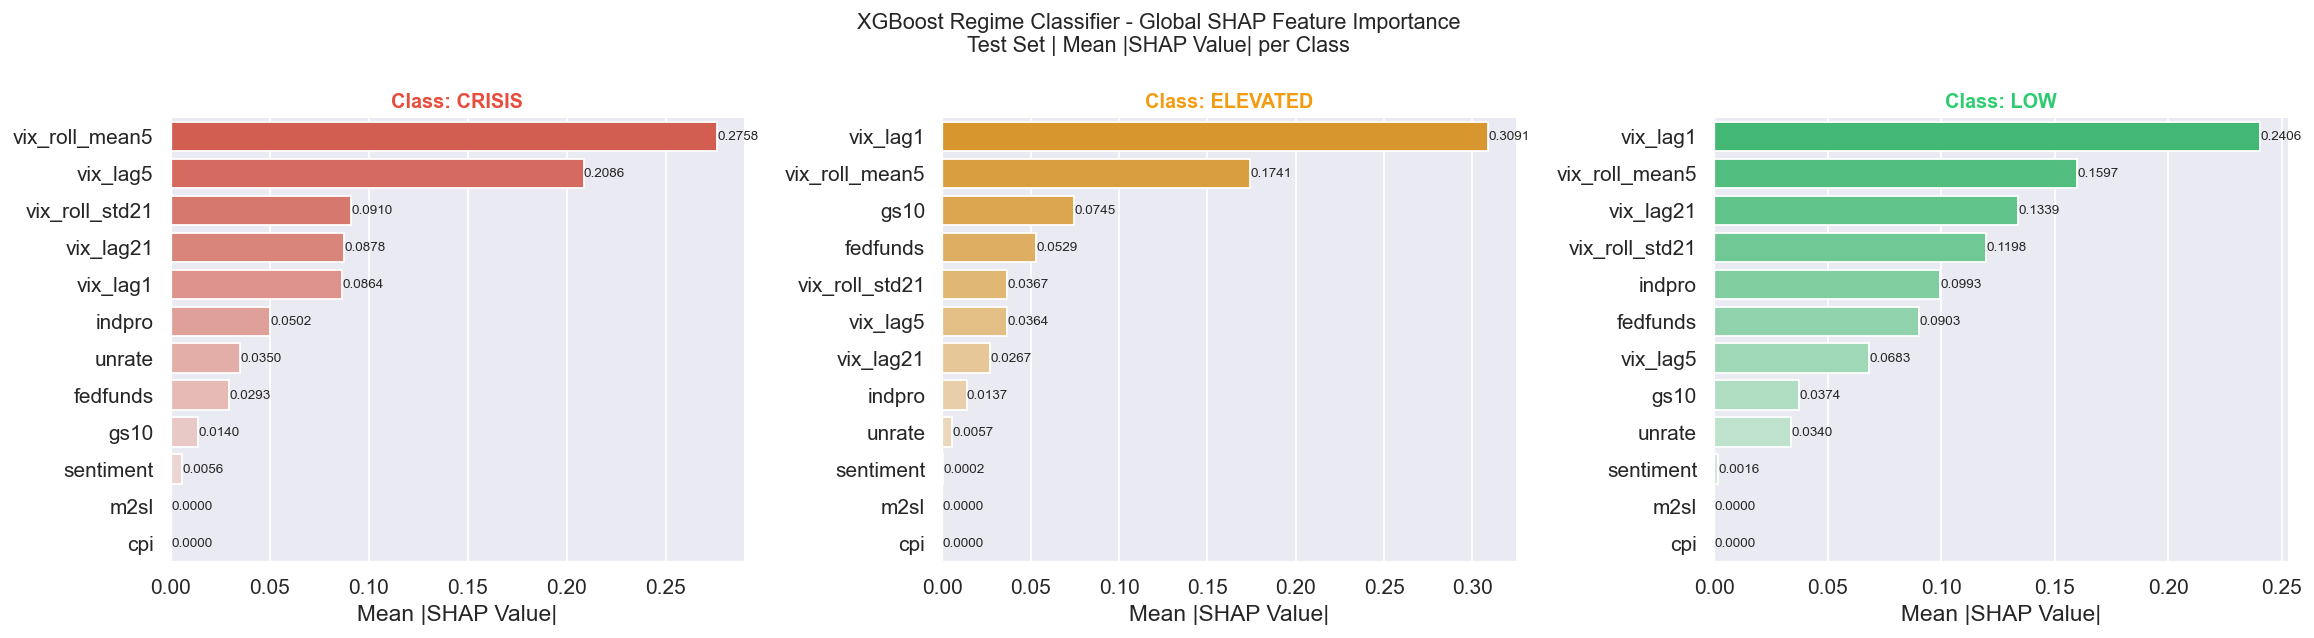


Top 3 SHAP drivers per class:
  CRISIS    : [('vix_roll_mean5', 0.2758), ('vix_lag5', 0.2086), ('vix_roll_std21', 0.091)]
  ELEVATED  : [('vix_lag1', 0.3091), ('vix_roll_mean5', 0.1741), ('gs10', 0.0745)]
  LOW       : [('vix_lag1', 0.2406), ('vix_roll_mean5', 0.1597), ('vix_lag21', 0.1339)]


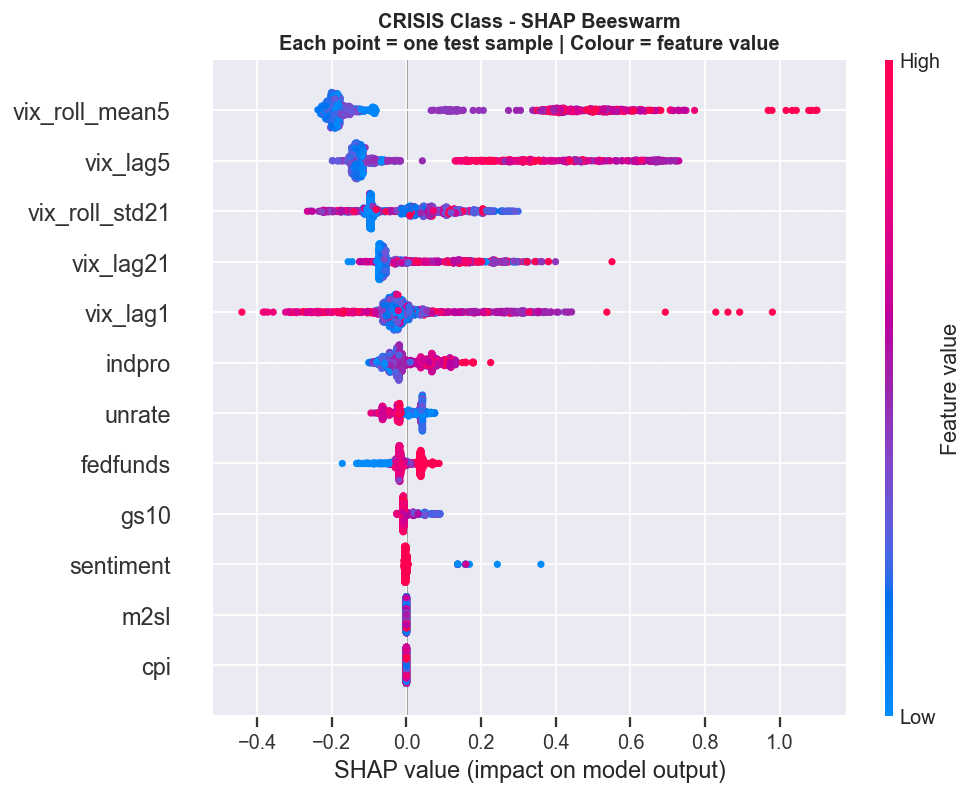

Computing SHAP interaction values (may take ~60s on CPU)...


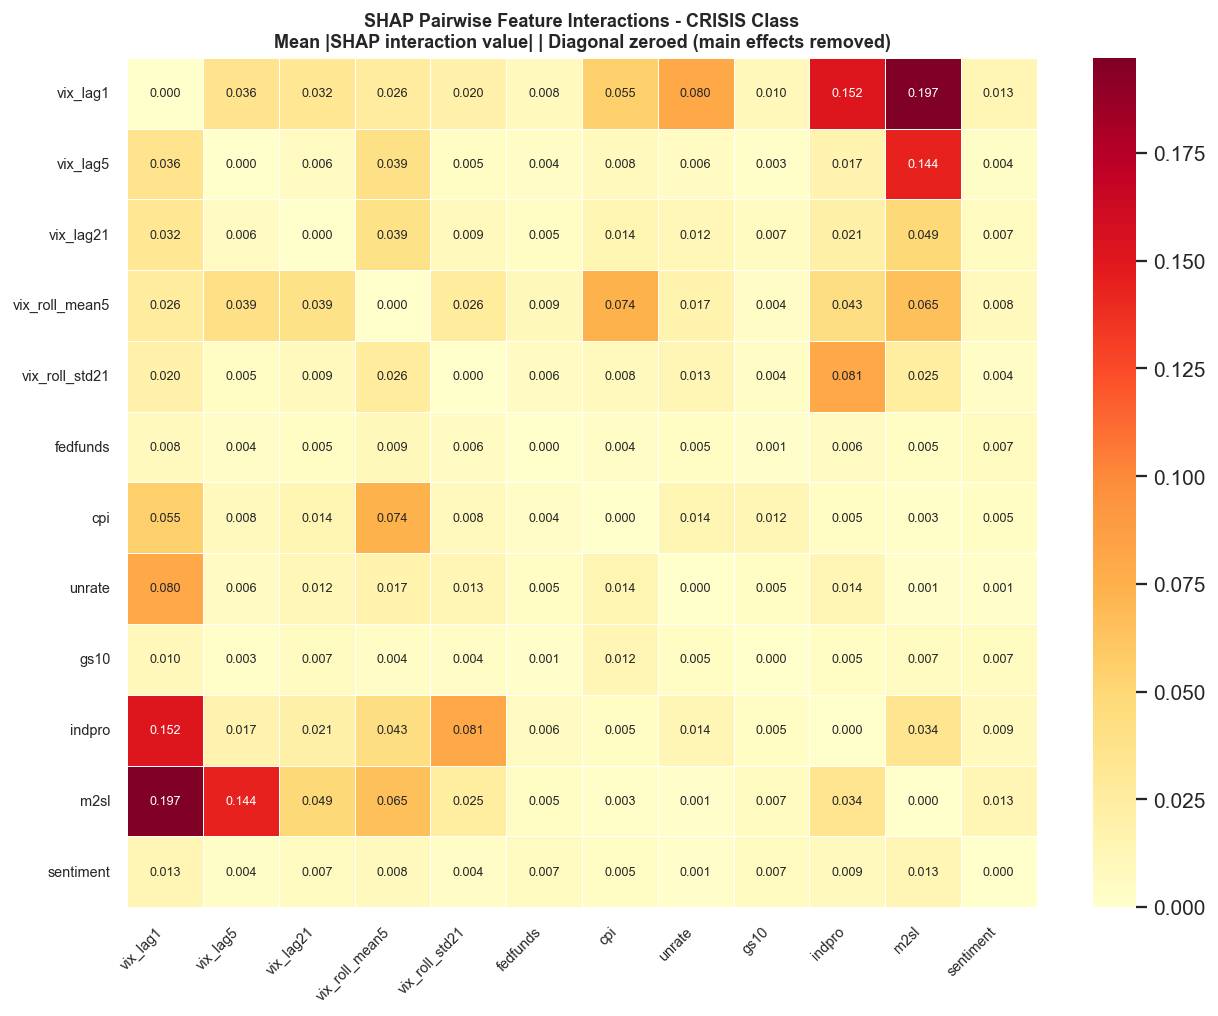


Top 5 CRISIS feature interaction pairs:
  vix_lag1 x m2sl                 : 0.1971
  vix_lag1 x indpro               : 0.1516
  vix_lag5 x m2sl                 : 0.1445
  vix_roll_std21 x indpro               : 0.0807
  vix_lag1 x unrate               : 0.0803


In [11]:
from IPython.display import Image, display

X_te_xgb = df[clf_feature_cols][df.index > VAL_END].dropna().values


explainer_xgb = shap.Explainer(clf, X_te_xgb)
shap_exp      = explainer_xgb(X_te_xgb)

# shap_exp.values shape: (N, n_features, n_classes)
shap_values = [shap_exp.values[:, :, i] for i in range(shap_exp.values.shape[2])]
print(f'SHAP computed | n_classes={len(shap_values)} | shape per class: {shap_values[0].shape}')

# Plot 1: Global mean |SHAP| bar chart — all 3 classes 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'XGBoost Regime Classifier - Global SHAP Feature Importance\n'
    'Test Set | Mean |SHAP Value| per Class',
    fontsize=12
)

for cls_i, cls_name in enumerate(le.classes_):
    ax       = axes[cls_i]
    mean_abs = np.abs(shap_values[cls_i]).mean(axis=0)
    sidx     = np.argsort(mean_abs)[::-1]
    feat_n   = np.array(clf_feature_cols)[sidx]
    feat_s   = mean_abs[sidx]

    pal = sns.light_palette(REGIME_COLORS[cls_name], n_colors=len(feat_n), reverse=True)
    sns.barplot(x=feat_s, y=feat_n, palette=pal, ax=ax, orient='h')
    ax.set_title(f'Class: {cls_name}', color=REGIME_COLORS[cls_name], fontweight='bold')
    ax.set_xlabel('Mean |SHAP Value|')
    if cls_i > 0:
        ax.set_ylabel('')
    for i, v in enumerate(feat_s):
        ax.text(v + 0.0002, i, f'{v:.4f}', va='center', fontsize=7.5)

plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], 'p7_xgb_shap_global.png'), dpi=130, bbox_inches='tight')
plt.close()
display(Image(os.path.join(PATHS['figures'], 'p7_xgb_shap_global.png')))

print('\nTop 3 SHAP drivers per class:')
for cls_i, cls_name in enumerate(le.classes_):
    mean_abs = np.abs(shap_values[cls_i]).mean(axis=0)
    top3     = np.argsort(mean_abs)[::-1][:3]
    drivers  = [(clf_feature_cols[i], round(float(mean_abs[i]), 4)) for i in top3]
    print(f'  {cls_name:<10}: {drivers}')

#  Plot 2: Beeswarm — CRISIS class 
crisis_idx = list(le.classes_).index('CRISIS')

crisis_exp = shap.Explanation(
    values      = shap_exp.values[:, :, crisis_idx],
    base_values = shap_exp.base_values[:, crisis_idx] if shap_exp.base_values.ndim == 2
                  else shap_exp.base_values,
    data          = shap_exp.data,
    feature_names = clf_feature_cols,
)

fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.beeswarm(crisis_exp, max_display=12, show=False)
plt.title('CRISIS Class - SHAP Beeswarm\nEach point = one test sample | Colour = feature value',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], 'p7_xgb_shap_beeswarm_crisis.png'), dpi=130, bbox_inches='tight')
plt.close()
display(Image(os.path.join(PATHS['figures'], 'p7_xgb_shap_beeswarm_crisis.png')))

# Plot 3: SHAP interaction heatmap — CRISIS class 
print('Computing SHAP interaction values (may take ~60s on CPU)...')
explainer_interact = shap.TreeExplainer(clf, model_output='raw')
shap_interact_raw  = explainer_interact.shap_interaction_values(X_te_xgb)

if isinstance(shap_interact_raw, list):
    shap_interact = np.stack(shap_interact_raw, axis=-1)
else:
    shap_interact = shap_interact_raw

interact_crisis = np.abs(shap_interact[:, :, :, crisis_idx]).mean(axis=0)
np.fill_diagonal(interact_crisis, 0)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    interact_crisis,
    xticklabels = clf_feature_cols,
    yticklabels = clf_feature_cols,
    cmap        = 'YlOrRd',
    linewidths  = 0.4,
    linecolor   = 'white',
    annot       = True,
    fmt         = '.3f',
    annot_kws   = {'size': 7},
    ax          = ax
)
ax.set_title(
    'SHAP Pairwise Feature Interactions - CRISIS Class\n'
    'Mean |SHAP interaction value| | Diagonal zeroed (main effects removed)',
    fontsize=10, fontweight='bold'
)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], 'p7_xgb_shap_interactions.png'), dpi=130, bbox_inches='tight')
plt.close()
display(Image(os.path.join(PATHS['figures'], 'p7_xgb_shap_interactions.png')))

pairs = []
for i in range(len(clf_feature_cols)):
    for j in range(i+1, len(clf_feature_cols)):
        pairs.append((interact_crisis[i, j], clf_feature_cols[i], clf_feature_cols[j]))
pairs.sort(reverse=True)
print('\nTop 5 CRISIS feature interaction pairs:')
for val, f1, f2 in pairs[:5]:
    print(f'  {f1} x {f2:<20} : {val:.4f}')

## Cell 7 - Per-Regime SHAP Breakdown: XGBoost 

Phase 6 showed global SHAP values across all test samples. This cell splits the test set by *true* regime and computes SHAP rankings within each subset.

**Why this matters:** `vix_roll_std21` may dominate CRISIS predictions but be irrelevant during LOW periods. Feature importance that varies by regime reveals that the classifier uses genuinely different decision logic across market conditions, a finding that directly motivates per-regime bulletin text in Phase 8.

Output: a `regime_shap_df` table saved to `models/regime_shap_summary.csv` and loaded by `get_top_drivers()`.

X_te_aligned     : (1057, 12)
regime_labels_te : (1057,)


 96%|=================== | 1932/2016 [00:15<00:00]       

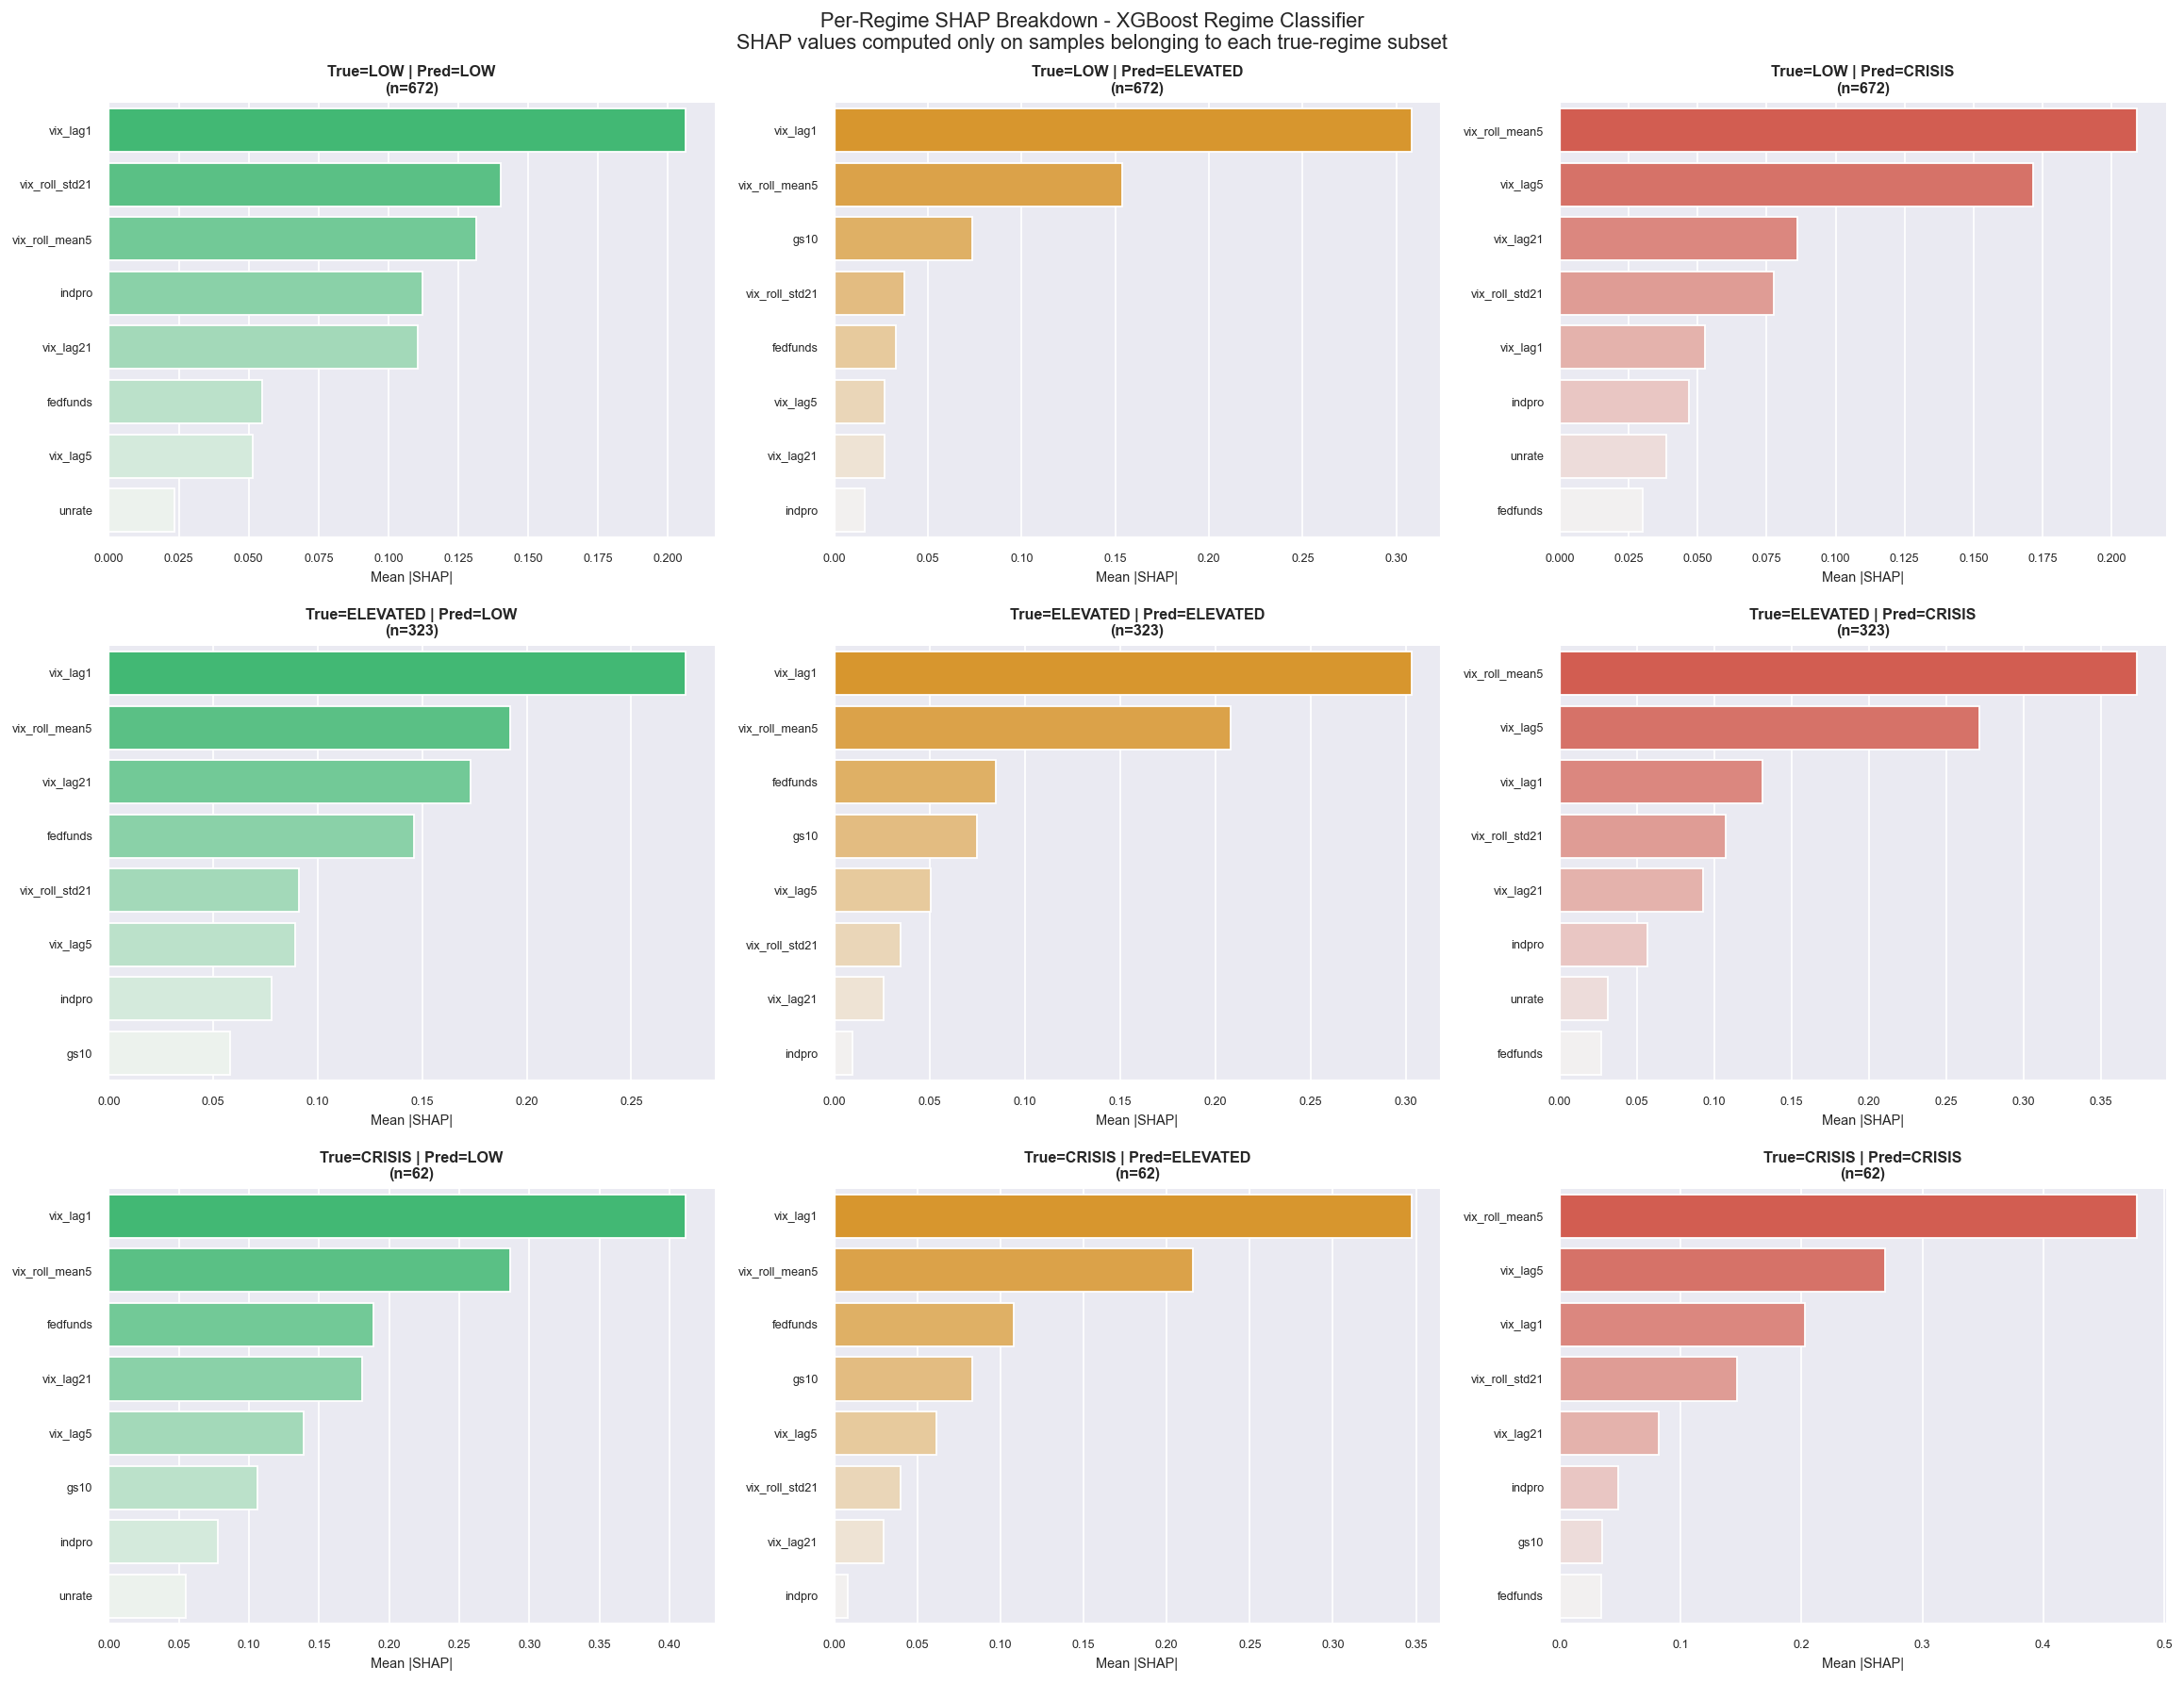

Saved per-regime SHAP summary -> C:\Users\sabin\genai-market\models\regime_shap_summary.csv


In [ ]:

#  Build regime labels aligned to XGBoost test set
X_te_xgb_full = df[clf_feature_cols][df.index > VAL_END].dropna().values

feat_df_xgb    = df[clf_feature_cols].copy()
regime_target  = df['regime_label'].shift(-5)
valid_mask_xgb = feat_df_xgb.notna().all(axis=1) & regime_target.notna()

#  Build aligned arrays from the SAME valid_mask used for labels
X_te_aligned       = feat_df_xgb[valid_mask_xgb][feat_df_xgb[valid_mask_xgb].index > VAL_END].values
regime_labels_te   = regime_target[valid_mask_xgb][feat_df_xgb[valid_mask_xgb].index > VAL_END].values

print(f'X_te_aligned     : {X_te_aligned.shape}')
print(f'regime_labels_te : {regime_labels_te.shape}')
assert len(regime_labels_te) == len(X_te_aligned), \
    f'Alignment error: {len(regime_labels_te)} labels vs {len(X_te_aligned)} samples'

regime_shap_records = []

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle(
    'Per-Regime SHAP Breakdown - XGBoost Regime Classifier\n'
    'SHAP values computed only on samples belonging to each true-regime subset',
    fontsize=12
)

for row_i, true_regime in enumerate(REGIME_ORDER):
    mask   = regime_labels_te == true_regime
    n_samp = mask.sum()
    if n_samp == 0:
        continue

    X_sub   = X_te_aligned[mask]
    sv_exp  = explainer_xgb(X_sub)
    sv_list = [sv_exp.values[:, :, i] for i in range(sv_exp.values.shape[2])]

    for col_i, pred_class in enumerate(REGIME_ORDER):
        ax       = axes[row_i, col_i]
        cls_idx  = list(le.classes_).index(pred_class)
        mean_abs = np.abs(sv_list[cls_idx]).mean(axis=0)
        sidx     = np.argsort(mean_abs)[::-1][:8]
        feat_n   = np.array(clf_feature_cols)[sidx]
        feat_s   = mean_abs[sidx]

        pal = sns.light_palette(REGIME_COLORS[pred_class], n_colors=len(feat_n), reverse=True)
        sns.barplot(x=feat_s, y=feat_n, palette=pal, ax=ax, orient='h')
        ax.set_title(
            f'True={true_regime} | Pred={pred_class}\n(n={n_samp})',
            fontsize=9, fontweight='bold'
        )
        ax.set_xlabel('Mean |SHAP|', fontsize=8)
        ax.tick_params(axis='both', labelsize=7)
        if col_i > 0:
            ax.set_ylabel('')

        for fi, (fn, fv) in enumerate(zip(feat_n, feat_s)):
            regime_shap_records.append({
                'true_regime'  : true_regime,
                'pred_class'   : pred_class,
                'feature'      : fn,
                'mean_abs_shap': round(float(fv), 6),
                'rank'         : fi + 1,
            })

plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], 'p7_xgb_shap_by_regime.png'), dpi=130, bbox_inches='tight')
plt.close()
display(Image(os.path.join(PATHS['figures'], 'p7_xgb_shap_by_regime.png')))

regime_shap_df   = pd.DataFrame(regime_shap_records)
regime_shap_path = os.path.join(PROJECT_ROOT, 'models', 'regime_shap_summary.csv')
regime_shap_df.to_csv(regime_shap_path, index=False)
print(f'Saved per-regime SHAP summary -> {regime_shap_path}')

---
# Part 2 - LSTM: Permutation Feature Importance
---

## Cell 8 - Permutation Feature Importance on the LSTM

`GradientExplainer` and `DeepExplainer` both fail on this architecture because the custom
`Attention` layer breaks the additivity assumption that SHAP gradient methods require.
**Permutation importance** is the correct alternative as it is completely model-agnostic and
works on any architecture without inspecting gradients or internals.

**Method:** For each feature, shuffle its values randomly across all test samples and measure
how much the LSTM's MAE increases. A large drop in performance = that feature genuinely
mattered. A small drop = the model can predict almost as well without it.



In [20]:

from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator

N_REPEATS = 10  # number of shuffle repeats per feature — higher = more stable

def lstm_predict_flat(X_flat):
    """
    Takes (N, n_features) flat features — the last timestep of each window.
    Reconstructs a minimal (N, 60, 12) tensor by tiling and runs LSTM inference.
    Returns (N, 3) log-space predictions.
    """
    model.eval()
    # Tile the flat features across 60 timesteps as a proxy window
    X_seq = np.tile(X_flat[:, np.newaxis, :], (1, SEQUENCE_LENGTH, 1)).astype(np.float32)
    X_t   = torch.tensor(X_seq).to(DEVICE)
    with torch.no_grad():
        out, _ = model(X_t)
    return out.cpu().numpy()  # (N, 3)


# Use flat last-timestep features for permutation importance
X_perm  = te_X_flat                          # (N_test, 12)
y_perm  = te_true_log[:, 1]                  # t+5 true log-VIX as target

# Score function: negative MAE (higher = better)
def score_fn(X):
    preds = lstm_predict_flat(X)[:, 1]       # t+5 horizon
    return -float(np.mean(np.abs(preds - y_perm[:len(preds)])))

baseline_score = score_fn(X_perm)
print(f'Baseline score (neg MAE): {baseline_score:.6f}')

lstm_shap_per_horizon = {}
perm_importance_records = []

for h_i, (horizon, hname) in enumerate(zip(HORIZONS, HORIZON_NAMES)):
    print(f'\nPermutation importance for {hname}...')
    h_target = te_true_log[:, h_i]

    importances = []
    for feat_i, feat_name in enumerate(FEATURE_COLS):
        feat_scores = []
        for rep in range(N_REPEATS):
            X_perm_copy = X_perm.copy()
            rng.shuffle(X_perm_copy[:, feat_i])  # shuffle one feature
            preds = lstm_predict_flat(X_perm_copy)[:, h_i]
            score = -float(np.mean(np.abs(preds - h_target[:len(preds)])))
            feat_scores.append(baseline_score - score)  # drop in score = importance
        mean_imp = float(np.mean(feat_scores))
        importances.append(mean_imp)
        print(f'  {feat_name:<20}: {mean_imp:.6f}')

    imp_arr = np.array(importances)
    # Store as (N_test, 12) shaped array filled with the importance value
    # so downstream code that calls .mean(axis=0) still works correctly
    lstm_shap_per_horizon[horizon] = np.tile(imp_arr, (len(X_perm), 1))

    top3 = np.argsort(imp_arr)[::-1][:3]
    print(f'Top 3: {[(FEATURE_COLS[i], round(float(imp_arr[i]),6)) for i in top3]}')

    for fi, fn in enumerate(FEATURE_COLS):
        perm_importance_records.append({
            'horizon' : horizon,
            'feature' : fn,
            'importance': float(imp_arr[fi]),
        })

perm_df = pd.DataFrame(perm_importance_records)
perm_path = os.path.join(PROJECT_ROOT, 'models', 'lstm_perm_importance.csv')
perm_df.to_csv(perm_path, index=False)
print(f'\nSaved -> {perm_path}')
print('\nPermutation importance complete.')

Baseline score (neg MAE): -0.198070

Permutation importance for t+1 (next day)...
  vix_lag1            : 0.040008
  vix_lag5            : 0.022696
  vix_lag21           : -0.009805
  vix_roll_mean5      : 0.097345
  vix_roll_std21      : -0.009429
  fedfunds            : -0.018915
  cpi                 : -0.013154
  unrate              : -0.010626
  gs10                : -0.019645
  indpro              : -0.010191
  m2sl                : -0.010938
  sentiment           : -0.010627
Top 3: [('vix_roll_mean5', 0.097345), ('vix_lag1', 0.040008), ('vix_lag5', 0.022696)]

Permutation importance for t+5 (next week)...
  vix_lag1            : 0.044847
  vix_lag5            : 0.028851
  vix_lag21           : 0.008299
  vix_roll_mean5      : 0.095988
  vix_roll_std21      : 0.000209
  fedfunds            : -0.006157
  cpi                 : -0.002381
  unrate              : 0.000041
  gs10                : -0.006699
  indpro              : 0.000605
  m2sl                : -0.000425
  sentiment  

## Cell 9 - Plot: LSTM Permutation Importance per Forecast Horizon

Three panels - one per forecast horizon (t+1, t+5, t+10). Each bar shows how much MAE
increases when that feature is shuffled — larger bar = more important feature.

Comparing rankings across horizons reveals whether the LSTM uses the same information
for a 1-day forecast as for a 2-week forecast. Features like `vix_lag1` are expected to
dominate at t+1 (recent VIX is the best short-term predictor) while macro variables like
`fedfunds` and `gs10` are expected to matter more at t+10 where medium-term economic
conditions drive regime transitions.

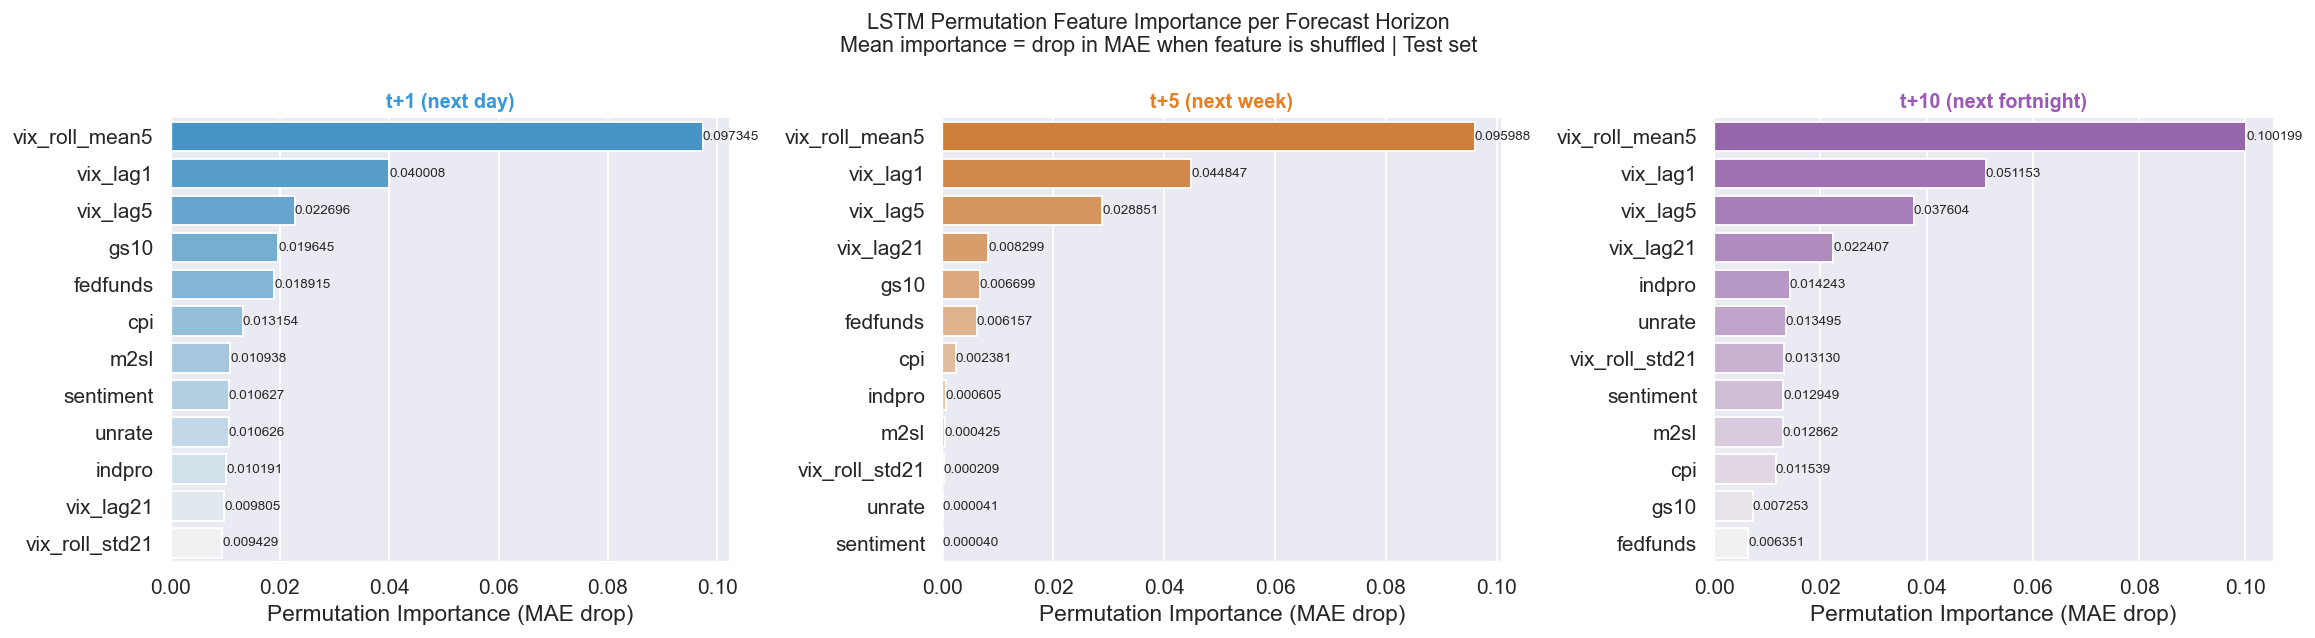

Top 3 LSTM permutation importance drivers per horizon:
  t+1 (next day)        : [('vix_roll_mean5', 0.097345), ('vix_lag1', 0.040008), ('vix_lag5', 0.022696)]
  t+5 (next week)       : [('vix_roll_mean5', 0.095988), ('vix_lag1', 0.044847), ('vix_lag5', 0.028851)]
  t+10 (next fortnight) : [('vix_roll_mean5', 0.100199), ('vix_lag1', 0.051153), ('vix_lag5', 0.037604)]


In [21]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'LSTM Permutation Feature Importance per Forecast Horizon\n'
    'Mean importance = drop in MAE when feature is shuffled | Test set',
    fontsize=12
)

horizon_colors = ['#3498db', '#e67e22', '#9b59b6']

for h_i, (horizon, hname) in enumerate(zip(HORIZONS, HORIZON_NAMES)):
    ax       = axes[h_i]
    sv_feat  = lstm_shap_per_horizon[horizon]
    mean_abs = np.abs(sv_feat).mean(axis=0)
    sidx     = np.argsort(mean_abs)[::-1]
    feat_n   = np.array(FEATURE_COLS)[sidx]
    feat_s   = mean_abs[sidx]

    pal = sns.light_palette(horizon_colors[h_i], n_colors=len(feat_n), reverse=True)
    sns.barplot(x=feat_s, y=feat_n, palette=pal, ax=ax, orient='h')
    ax.set_title(hname, color=horizon_colors[h_i], fontweight='bold')
    ax.set_xlabel('Permutation Importance (MAE drop)')
    if h_i > 0:
        ax.set_ylabel('')
    for i, v in enumerate(feat_s):
        ax.text(v + 1e-7, i, f'{v:.6f}', va='center', fontsize=7.5)

plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], 'p7_lstm_shap_per_horizon.png'), dpi=130, bbox_inches='tight')
plt.close()
display(Image(os.path.join(PATHS['figures'], 'p7_lstm_shap_per_horizon.png')))

print('Top 3 LSTM permutation importance drivers per horizon:')
for horizon, hname in zip(HORIZONS, HORIZON_NAMES):
    mean_abs = np.abs(lstm_shap_per_horizon[horizon]).mean(axis=0)
    top3     = np.argsort(mean_abs)[::-1][:3]
    drivers  = [(FEATURE_COLS[i], round(float(mean_abs[i]), 6)) for i in top3]
    print(f'  {hname:<22}: {drivers}')

---
# Part 3 - Attention Profiles by Regime: LOW vs ELEVATED vs CRISIS
---

## Cell 10 - Attention × Permutation Importance Fusion Heatmap

**Why the outer product is valid here:** Attention tells us the model's focus across time.
Permutation importance tells us each feature's global value. Their product gives a principled
approximation of joint attribution without requiring gradient access into the attention layer.


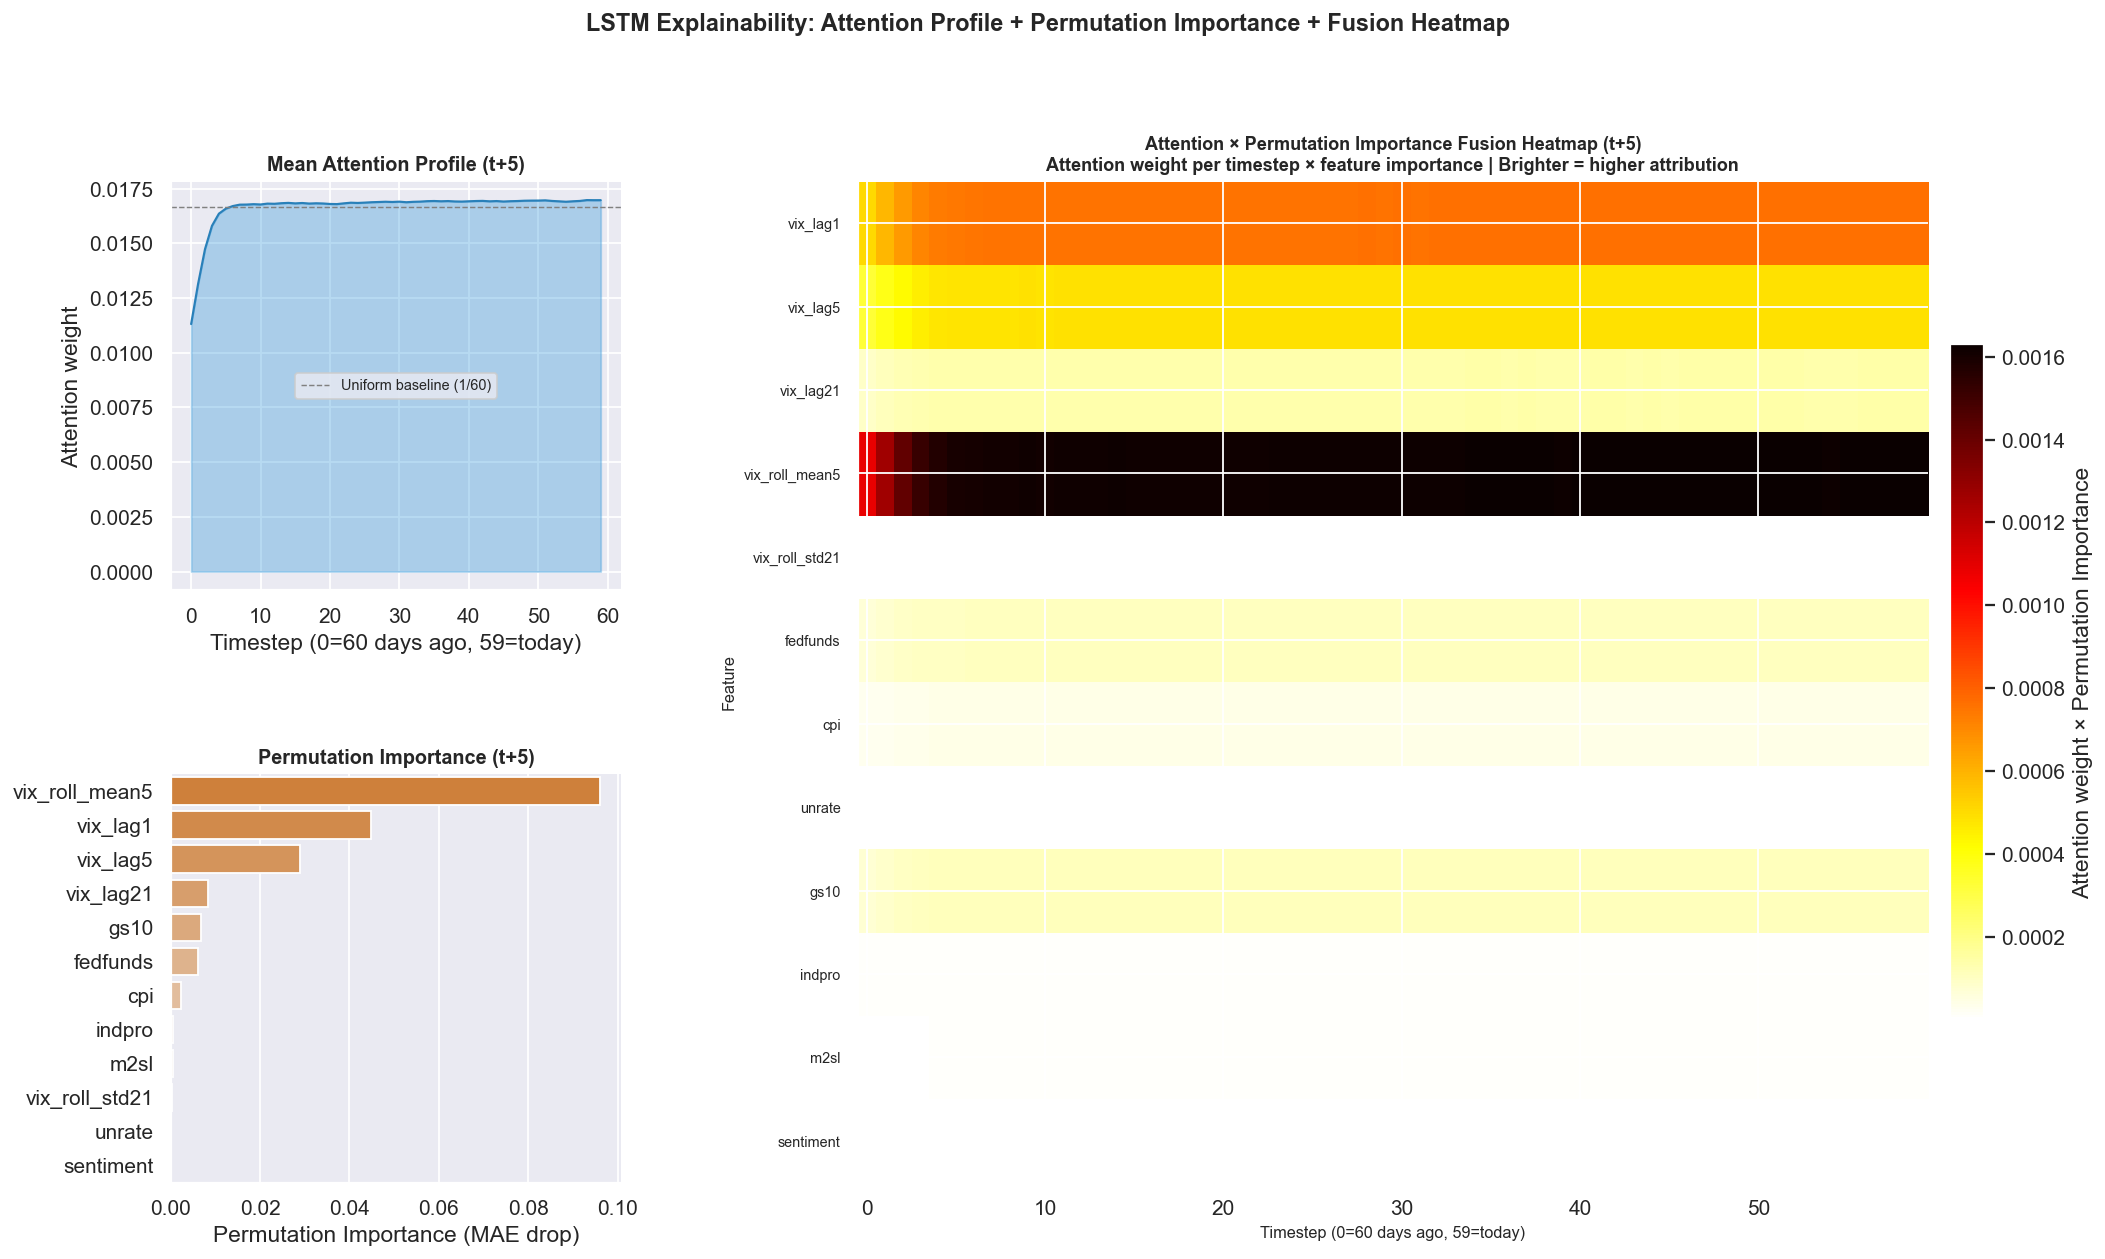

Saved: p7_attn_shap_fusion.png


In [23]:

# Mean attention profile 
attn_shap_idx = shap_test_idx
mean_attn     = te_attn[attn_shap_idx].mean(axis=0)   # (60,)

#  Fusion matrix: attention × permutation importance 
# outer product: attention (60,) x importance (12,) -> (60, 12)
imp_t5        = np.abs(lstm_shap_per_horizon[5]).mean(axis=0)   # (12,)
fusion_matrix = mean_attn[:, np.newaxis] * imp_t5[np.newaxis, :]  # (60, 12)

#  Plot 
fig = plt.figure(figsize=(18, 10))
gs  = fig.add_gridspec(2, 2, width_ratios=[1, 2.5], height_ratios=[1, 1], hspace=0.45, wspace=0.3)

ax_attn = fig.add_subplot(gs[0, 0])
ax_shap = fig.add_subplot(gs[1, 0])
ax_hmap = fig.add_subplot(gs[:, 1])

# Attention profile
timesteps = np.arange(SEQUENCE_LENGTH)
ax_attn.fill_between(timesteps, mean_attn, alpha=0.35, color='#3498db')
ax_attn.plot(timesteps, mean_attn, color='#2980b9', linewidth=1.2)
ax_attn.axhline(1 / SEQUENCE_LENGTH, color='gray', linestyle='--', linewidth=0.8,
                label='Uniform baseline (1/60)')
ax_attn.set_title('Mean Attention Profile (t+5)', fontweight='bold')
ax_attn.set_xlabel('Timestep (0=60 days ago, 59=today)')
ax_attn.set_ylabel('Attention weight')
ax_attn.legend(fontsize=8)

# Permutation importance per feature (t+5)
sv5_feat  = lstm_shap_per_horizon[5]
mean_abs5 = np.abs(sv5_feat).mean(axis=0)
sidx5     = np.argsort(mean_abs5)[::-1]
pal5 = sns.light_palette('#e67e22', n_colors=N_FEATURES, reverse=True)
sns.barplot(x=mean_abs5[sidx5], y=np.array(FEATURE_COLS)[sidx5],
            palette=pal5, ax=ax_shap, orient='h')
ax_shap.set_title('Permutation Importance (t+5)', fontweight='bold')
ax_shap.set_xlabel('Permutation Importance (MAE drop)')

# Fusion heatmap (60 timesteps x 12 features)
im = ax_hmap.imshow(fusion_matrix.T, aspect='auto', cmap='hot_r', interpolation='nearest')
ax_hmap.set_xlabel('Timestep (0=60 days ago, 59=today)', fontsize=9)
ax_hmap.set_ylabel('Feature', fontsize=9)
ax_hmap.set_yticks(range(N_FEATURES))
ax_hmap.set_yticklabels(FEATURE_COLS, fontsize=8)
ax_hmap.set_title(
    'Attention × Permutation Importance Fusion Heatmap (t+5)\n'
    'Attention weight per timestep × feature importance | Brighter = higher attribution',
    fontweight='bold', fontsize=10
)
plt.colorbar(im, ax=ax_hmap, fraction=0.03, pad=0.02,
             label='Attention weight × Permutation Importance')

fig.suptitle(
    'LSTM Explainability: Attention Profile + Permutation Importance + Fusion Heatmap',
    fontsize=13, fontweight='bold', y=1.01
)
plt.savefig(os.path.join(PATHS['figures'], 'p7_attn_shap_fusion.png'),
            dpi=130, bbox_inches='tight')
plt.close()
display(Image(os.path.join(PATHS['figures'], 'p7_attn_shap_fusion.png')))
print('Saved: p7_attn_shap_fusion.png')

## Cell 11 - Attention Profiles by Regime: LOW vs ELEVATED vs CRISIS

Does the LSTM attend to different timesteps depending on which market regime it is
predicting into? This cell computes separate mean attention profiles for test samples
where the *true* 5-day-ahead regime is LOW, ELEVATED, or CRISIS.


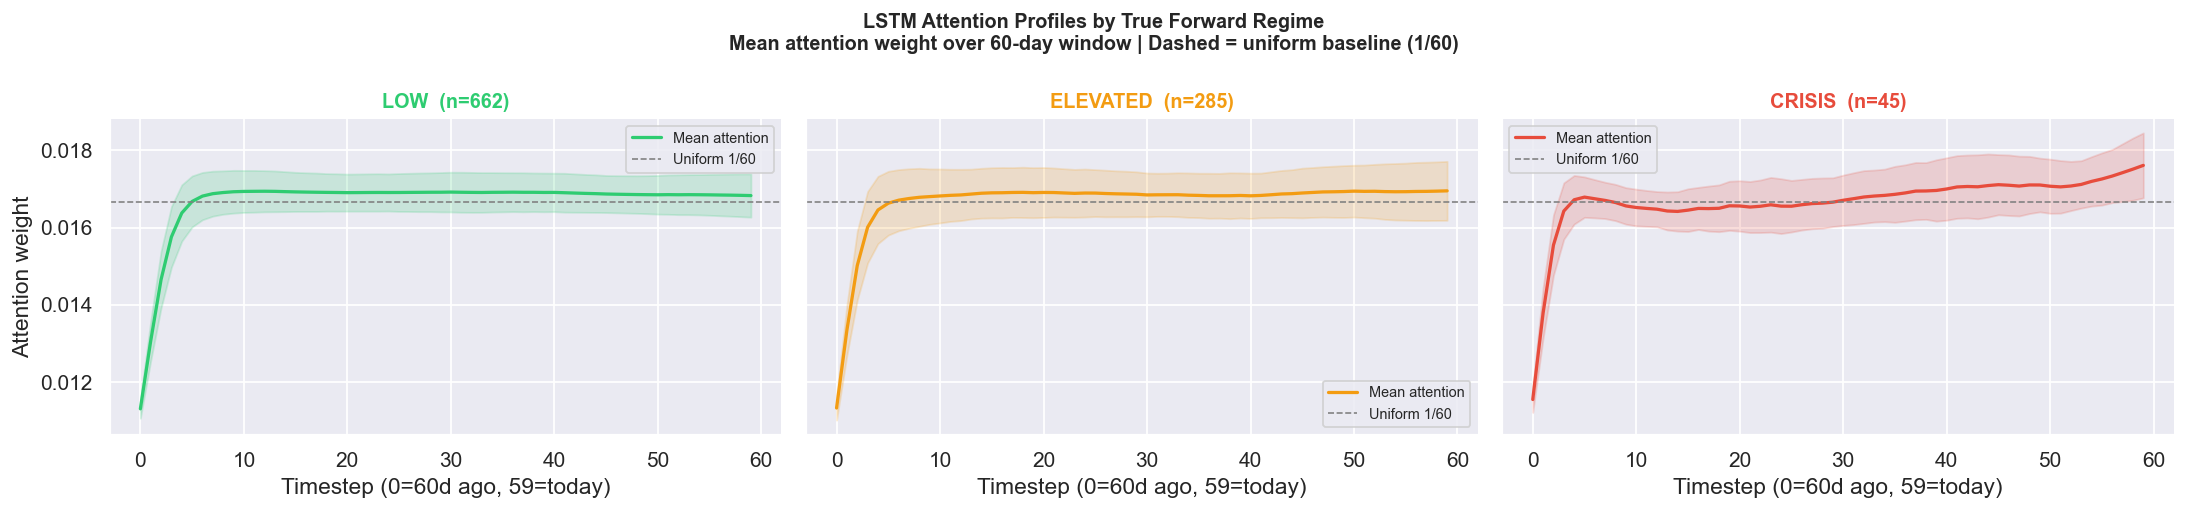

  LOW       : peak attention at timestep 12 (48 days ago) | weight=0.0169
  ELEVATED  : peak attention at timestep 59 (1 days ago) | weight=0.0169
  CRISIS    : peak attention at timestep 59 (1 days ago) | weight=0.0176


In [24]:
from IPython.display import Image, display

te_ds      = VIXDataset(test_df, FEATURE_COLS, sequence_length=SEQUENCE_LENGTH, horizons=HORIZONS)
te_regimes = np.array([
    test_df['regime_label'].iloc[idx + 5]
    if (idx + 5) < len(test_df) else 'LOW'
    for idx in te_ds.indices
])

fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharey=True)
fig.suptitle(
    'LSTM Attention Profiles by True Forward Regime\n'
    'Mean attention weight over 60-day window | Dashed = uniform baseline (1/60)',
    fontsize=11, fontweight='bold'
)

timesteps = np.arange(SEQUENCE_LENGTH)
uniform   = 1 / SEQUENCE_LENGTH

for i, regime in enumerate(REGIME_ORDER):
    mask     = te_regimes == regime
    n_samp   = mask.sum()
    color    = REGIME_COLORS[regime]
    ax       = axes[i]

    if n_samp == 0:
        ax.set_title(f'{regime} (no samples)')
        continue

    profile  = te_attn[mask].mean(axis=0)
    std_prof = te_attn[mask].std(axis=0)

    ax.fill_between(timesteps, profile - std_prof, profile + std_prof,
                    alpha=0.18, color=color)
    ax.plot(timesteps, profile, color=color, linewidth=1.8, label='Mean attention')
    ax.axhline(uniform, color='gray', linestyle='--', linewidth=0.9, label='Uniform 1/60')

    high_mask = profile > 1.5 * uniform
    ax.scatter(timesteps[high_mask], profile[high_mask], color=color, s=20, zorder=5)

    ax.set_title(f'{regime}  (n={n_samp})', color=color, fontweight='bold')
    ax.set_xlabel('Timestep (0=60d ago, 59=today)')
    if i == 0:
        ax.set_ylabel('Attention weight')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], 'p7_attn_profiles_by_regime.png'), dpi=130, bbox_inches='tight')
plt.close()
display(Image(os.path.join(PATHS['figures'], 'p7_attn_profiles_by_regime.png')))

for regime in REGIME_ORDER:
    mask    = te_regimes == regime
    if mask.sum() == 0:
        continue
    profile = te_attn[mask].mean(axis=0)
    peak_ts = int(np.argmax(profile))
    peak_wt = float(profile[peak_ts])
    print(f'  {regime:<10}: peak attention at timestep {peak_ts} ({60 - peak_ts} days ago) | weight={peak_wt:.4f}')

---
# Part 4 - Granger Causality Tests
---

## Cell 12 - Granger Causality Tests with Sentiment Exclusion

Phase 4 ran Granger causality tests on the full dataset including 57.8% of days where
`sentiment_source == 'default_neutral'` - pre-2009 gap-filled zeros. Running the sentiment
Granger test on that data inflates the sample with synthetic values that carry no real signal.
The `sentiment_source` column was added in Phase 3 precisely to allow excluding those days.

Two Granger tests are run for sentiment: one on the full dataset (Phase 4 equivalent, kept
for comparison) and one restricted to post-2009 FinBERT-scored rows only. All six macro
variables are tested at lags `[1, 5, 10, 21]` on the full dataset. Significance threshold
is p < 0.05, with stars indicating p < 0.001 (`***`), p < 0.01 (`**`), and p < 0.05 (`*`).

Results are saved to `models/granger_results.csv` and visualised as a p-value heatmap..

In [25]:
from statsmodels.tsa.stattools import grangercausalitytests

MACRO_VARS = ['fedfunds', 'cpi', 'unrate', 'gs10', 'indpro', 'm2sl']
TEST_VARS  = MACRO_VARS + ['sentiment']   # sentiment tested twice (full vs finbert)


def run_granger(series_y, series_x, lags, label):
    """Return dict of {lag: p_value} for grangercausalitytests(ssr_ftest)."""
    data   = pd.concat([series_y, series_x], axis=1).dropna()
    result = {}
    for lag in lags:
        try:
            gc = grangercausalitytests(data.values, maxlag=lag, verbose=False)
            p  = gc[lag][0]['ssr_ftest'][1]
            result[lag] = p
        except Exception:
            result[lag] = np.nan
    return result


def sig_stars(p):
    if   p < 0.001: return '***'
    elif p < 0.01:  return '**'
    elif p < 0.05:  return '*'
    else:           return ''


vix_log_full   = df['vix_log']
finbert_mask   = df['sentiment_source'] == 'finbert'

granger_records = []
print(f'Running Granger causality tests at lags {GRANGER_LAGS}...')
print(f'{"Variable":<22} {"Scope":<12}', end='')
for lag in GRANGER_LAGS:
    print(f'  lag={lag:<3}', end='')
print()
print('-' * 75)

for var in MACRO_VARS:
    res = run_granger(vix_log_full, df[var], GRANGER_LAGS, 'full')
    row = {'variable': var, 'scope': 'full'}
    print(f'{var:<22} {"full":<12}', end='')
    for lag in GRANGER_LAGS:
        p = res[lag]
        row[f'lag_{lag}'] = round(p, 4) if not np.isnan(p) else np.nan
        stars = sig_stars(p) if not np.isnan(p) else 'NaN'
        print(f'  {p:.4f}{stars:<3}', end='')
    print()
    granger_records.append(row)

#  Sentiment — full dataset
for scope, mask in [('full', slice(None)), ('finbert_only', finbert_mask)]:
    y_s = vix_log_full[mask] if scope == 'finbert_only' else vix_log_full
    x_s = df['sentiment'][mask] if scope == 'finbert_only' else df['sentiment']
    res = run_granger(y_s, x_s, GRANGER_LAGS, scope)
    row = {'variable': 'sentiment', 'scope': scope}
    print(f'{"sentiment":<22} {scope:<12}', end='')
    for lag in GRANGER_LAGS:
        p = res[lag]
        row[f'lag_{lag}'] = round(p, 4) if not np.isnan(p) else np.nan
        stars = sig_stars(p) if not np.isnan(p) else 'NaN'
        print(f'  {p:.4f}{stars:<3}', end='')
    print()
    granger_records.append(row)

granger_df = pd.DataFrame(granger_records)
granger_path = os.path.join(PROJECT_ROOT, 'models', 'granger_results.csv')
granger_df.to_csv(granger_path, index=False)
print(f'\nSaved -> {granger_path}')

Running Granger causality tests at lags [1, 5, 10, 21]...
Variable               Scope         lag=1    lag=5    lag=10   lag=21 
---------------------------------------------------------------------------
fedfunds               full          0.6023     0.3217     0.1594     0.0725   
cpi                    full          0.4515     0.4479     0.7600     0.6584   
unrate                 full          0.1489     0.7531     0.7504     0.7446   
gs10                   full          0.5665     0.1629     0.1693     0.5670   
indpro                 full          0.0007***  0.2044     0.6093     0.7757   
m2sl                   full          0.5928     0.8322     0.1580     0.3815   
sentiment              full          0.6173     0.4131     0.1569     0.5821   
sentiment              finbert_only  0.3807     0.8265     0.7863     0.5579   

Saved -> C:\Users\sabin\genai-market\models\granger_results.csv


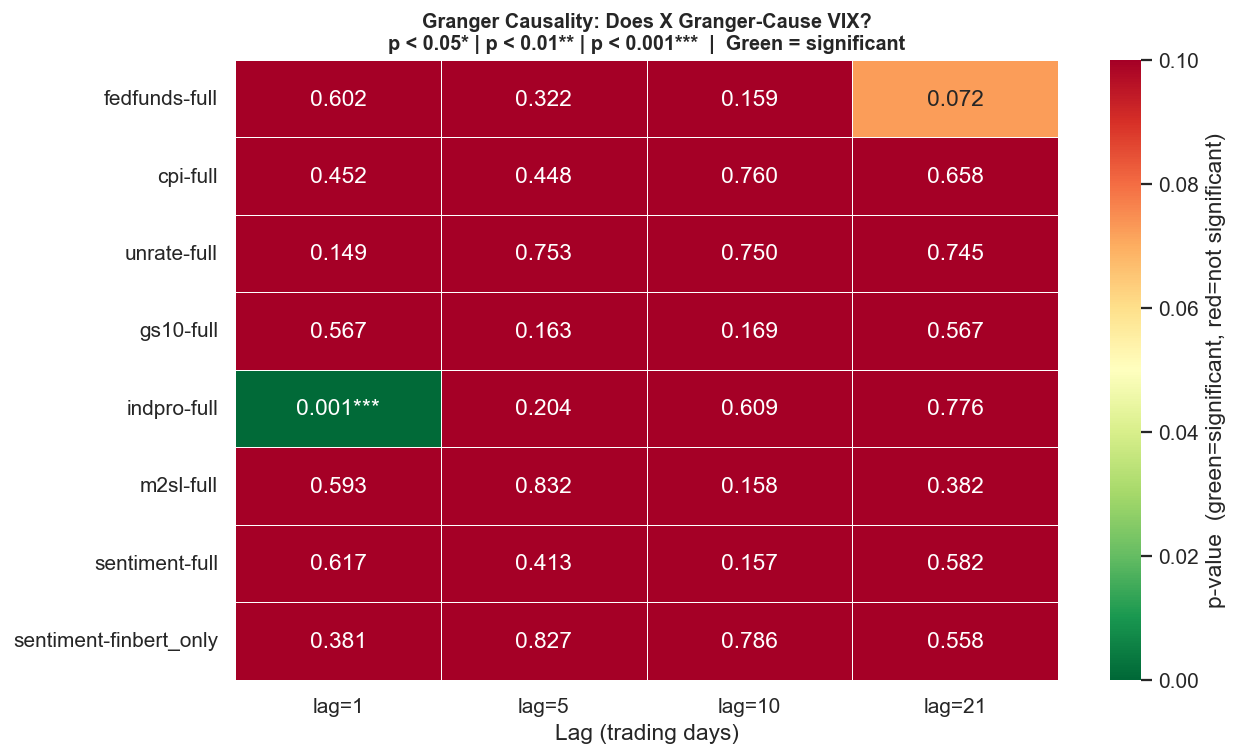


Key Granger findings:
  fedfunds       (full): not significant at any tested lag
  cpi            (full): not significant at any tested lag
  unrate         (full): not significant at any tested lag
  gs10           (full): not significant at any tested lag
  indpro         (full): significant at lags [1]
  m2sl           (full): not significant at any tested lag
  sentiment      (full): not significant at any tested lag
  sentiment      (finbert_only): not significant at any tested lag


In [26]:
import matplotlib.colors as mcolors

lag_cols     = [f'lag_{l}' for l in GRANGER_LAGS]
pivot_df     = granger_df.set_index(['variable', 'scope'])[lag_cols]

fig, ax = plt.subplots(figsize=(10, 6))

annot_matrix = pivot_df.copy().astype(str)
for idx in pivot_df.index:
    for col in lag_cols:
        p = pivot_df.loc[idx, col]
        annot_matrix.loc[idx, col] = f'{p:.3f}{sig_stars(p)}' if not np.isnan(p) else 'NaN'

sns.heatmap(
    pivot_df.astype(float),
    annot      = annot_matrix,
    fmt        = '',
    cmap       = 'RdYlGn_r',
    vmin       = 0, vmax=0.1,
    linewidths = 0.5,
    linecolor  = 'white',
    ax         = ax,
    cbar_kws   = {'label': 'p-value  (green=significant, red=not significant)'}
)
ax.set_title(
    'Granger Causality: Does X Granger-Cause VIX?\n'
    'p < 0.05* | p < 0.01** | p < 0.001***  |  Green = significant',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Lag (trading days)')
ax.set_ylabel('')
ax.set_xticklabels([f'lag={l}' for l in GRANGER_LAGS])
plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], 'p7_granger_heatmap.png'), dpi=130, bbox_inches='tight')
plt.close()
display(Image(os.path.join(PATHS['figures'], 'p7_granger_heatmap.png')))

print('\nKey Granger findings:')
for _, row in granger_df.iterrows():
    sig_lags = [l for l in GRANGER_LAGS
                if not np.isnan(row[f'lag_{l}']) and row[f'lag_{l}'] < 0.05]
    if sig_lags:
        print(f'  {row["variable"]:<14} ({row["scope"]}): significant at lags {sig_lags}')
    else:
        print(f'  {row["variable"]:<14} ({row["scope"]}): not significant at any tested lag')

---
# Part 5 - XGBoost SHAP Stability Check
---

## Cell 13 - XGBoost SHAP Stability Check

A feature importance ranking that changes substantially between two random subsets of the
test set is unreliable meaning the explanation is sensitive to which specific samples are
included and cannot be trusted in a production bulletin.

XGBoost SHAP values are computed on two independent random 60% subsets of the test set.
Feature rankings are compared using Spearman rank correlation. A value above 0.8 confirms
the rankings are stable and safe to use downstream. A value below 0.6 would indicate the
explanations are too noisy to report.

This check applies to the XGBoost regime classifier only. The LSTM uses permutation
importance (Part 2), which is inherently stable by construction since it measures actual
performance degradation rather than gradient-based attribution.

 96%|=================== | 1829/1911 [00:14<00:00]       

Subset 1 top-3 (CRISIS): [('vix_roll_mean5', 0.2728), ('vix_lag5', 0.2035), ('vix_roll_std21', 0.0899)]


 97%|=================== | 1849/1911 [00:15<00:00]       

Subset 2 top-3 (CRISIS): [('vix_roll_mean5', 0.2717), ('vix_lag5', 0.2006), ('vix_roll_std21', 0.0903)]

Spearman rank correlations between subsets:
  Subset 1 vs Subset 2: rho=1.0000  p=0.0000  -> STABLE

Mean Spearman rho : 1.0000
Overall stability : STABLE


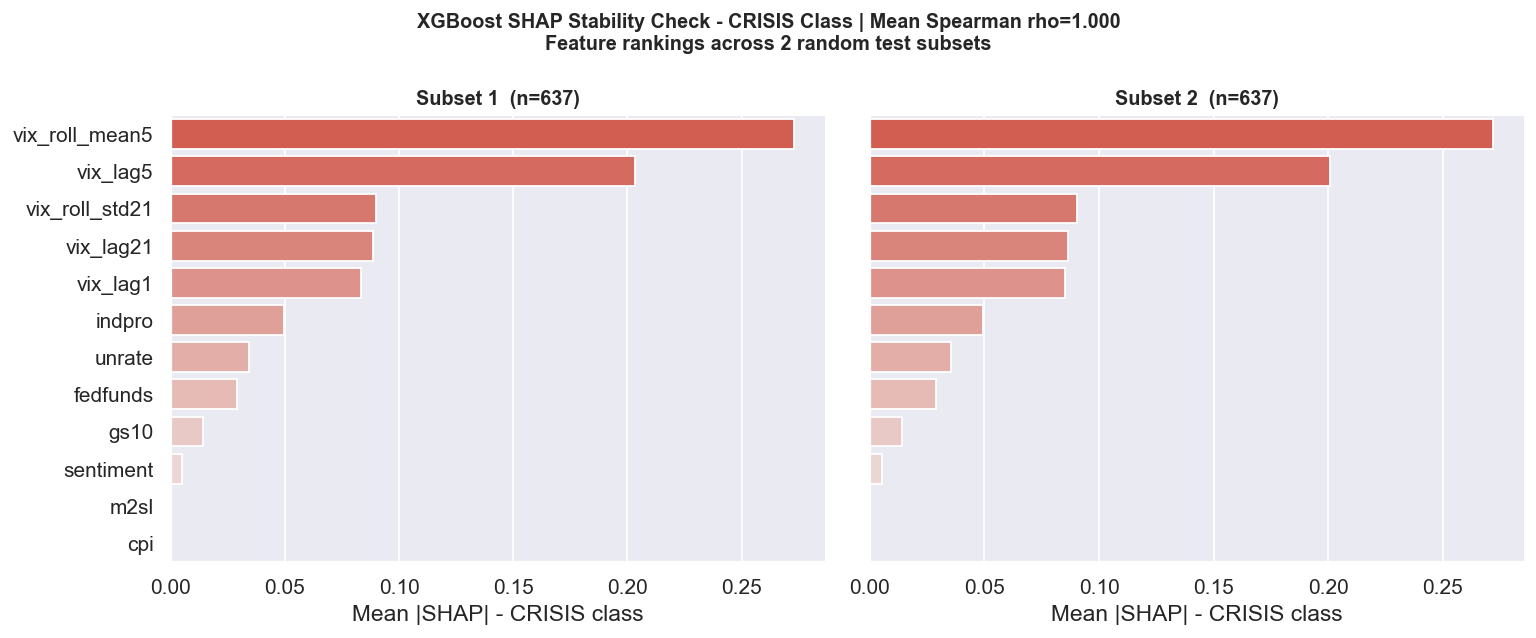

In [28]:
from scipy.stats import spearmanr

crisis_idx_cls = list(le.classes_).index('CRISIS')
n_test         = len(X_te_xgb)
subset_size    = int(n_test * STABILITY_FRAC)

subset_rankings = []
rng_stab        = np.random.default_rng(SEED + 99)

for split_i in range(STABILITY_SPLITS):
    idx_sub  = rng_stab.choice(n_test, size=subset_size, replace=False)
    X_sub    = X_te_xgb[idx_sub]
    sv_exp   = explainer_xgb(X_sub)
    sv_arr   = sv_exp.values[:, :, crisis_idx_cls]
    mean_abs = np.abs(sv_arr).mean(axis=0)
    ranks    = np.argsort(np.argsort(-mean_abs))
    subset_rankings.append({'mean_abs': mean_abs, 'ranks': ranks})
    top3 = np.argsort(mean_abs)[::-1][:3]
    print(f'Subset {split_i+1} top-3 (CRISIS): '
          f'{[(clf_feature_cols[i], round(float(mean_abs[i]),4)) for i in top3]}')

print('\nSpearman rank correlations between subsets:')
rho_values = []
for i in range(STABILITY_SPLITS):
    for j in range(i+1, STABILITY_SPLITS):
        rho, pval = spearmanr(subset_rankings[i]['ranks'], subset_rankings[j]['ranks'])
        rho_values.append(rho)
        stable = 'STABLE' if rho > 0.8 else ('BORDERLINE' if rho > 0.6 else 'UNSTABLE')
        print(f'  Subset {i+1} vs Subset {j+1}: rho={rho:.4f}  p={pval:.4f}  -> {stable}')

mean_rho = np.mean(rho_values)
print(f'\nMean Spearman rho : {mean_rho:.4f}')
print(f'Overall stability : {"STABLE" if mean_rho > 0.8 else ("BORDERLINE" if mean_rho > 0.6 else "UNSTABLE")}')

fig, axes = plt.subplots(1, STABILITY_SPLITS, figsize=(6 * STABILITY_SPLITS, 5), sharey=True)
if STABILITY_SPLITS == 1:
    axes = [axes]

for split_i, (ax, sr) in enumerate(zip(axes, subset_rankings)):
    sidx   = np.argsort(sr['mean_abs'])[::-1]
    feat_n = np.array(clf_feature_cols)[sidx]
    feat_s = sr['mean_abs'][sidx]
    pal    = sns.light_palette(REGIME_COLORS['CRISIS'], n_colors=len(feat_n), reverse=True)
    sns.barplot(x=feat_s, y=feat_n, palette=pal, ax=ax, orient='h')
    ax.set_title(f'Subset {split_i+1}  (n={subset_size})', fontweight='bold')
    ax.set_xlabel('Mean |SHAP| - CRISIS class')
    if split_i > 0:
        ax.set_ylabel('')

fig.suptitle(
    f'XGBoost SHAP Stability Check - CRISIS Class | Mean Spearman rho={mean_rho:.3f}\n'
    f'Feature rankings across {STABILITY_SPLITS} random test subsets',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], 'p7_shap_stability.png'), dpi=130, bbox_inches='tight')
plt.close()
display(Image(os.path.join(PATHS['figures'], 'p7_shap_stability.png')))

---
# Part 6 - `get_top_drivers()`: Production Function for Phase 8
---

## Cell 14 - `get_top_drivers()`: Per-Horizon, Per-Regime Driver Function

`get_top_drivers()` is the single function Phase 8 calls to populate every risk bulletin.
It accepts a feature vector, a current regime, and a forecast horizon, and returns a
ranked list of the features that drove that specific prediction drawn from two sources:

- **XGBoost SHAP** (regime-specific): which features most influenced the regime classification
- **LSTM permutation importance** (horizon-specific): which features most affected forecast
  accuracy when removed, at the requested horizon


Direction is inferred by comparing the current feature value to its training-set mean.
Features above their historical mean are labelled `elevated`, below are `depressed`,
and sentiment is labelled `positive` or `negative` based on sign.

In [29]:
#  Training-set feature means — used for direction inference
feat_means = train_df[FEATURE_COLS].mean()


def infer_direction(feature_name, feature_value, feature_mean):
    """Return human-readable direction of a feature relative to its historical mean."""
    delta = feature_value - feature_mean
    if abs(delta) < 0.05 * abs(feature_mean + 1e-8):
        return 'neutral'
    if 'sentiment' in feature_name:
        return 'negative' if feature_value < 0 else 'positive'
    return 'elevated' if delta > 0 else 'depressed'


def get_top_drivers(
    feature_vector  : np.ndarray,
    current_regime  : str,
    horizon         : int  = 5,
    top_n           : int  = 3,
    lstm_shap_dict  : dict = None,
    xgb_shap_values : list = None,
    granger_df      : pd.DataFrame = None,
    stability_rho   : float = None,
) -> dict:
    """
    Return the top feature drivers for a given prediction context.

    Combines XGBoost TreeExplainer SHAP (regime-specific) and
    LSTM permutation importance (horizon-specific).

    Parameters
    ----------
    feature_vector  : (n_features,) array for the current date
    current_regime  : 'LOW' | 'ELEVATED' | 'CRISIS'
    horizon         : forecast horizon in trading days (1, 5, or 10)
    top_n           : number of drivers to return
    lstm_shap_dict  : {horizon: (N, n_feat)} permutation importance arrays
    xgb_shap_values : list of 3 arrays (N, n_feat) from TreeExplainer
    granger_df      : DataFrame with Granger test results
    stability_rho   : mean Spearman rho from stability check

    Returns
    -------
    dict with top_drivers list and metadata
    """
    drivers = []

    #  XGBoost SHAP — regime-specific
    if xgb_shap_values is not None:
        cls_idx_map  = {r: i for i, r in enumerate(le.classes_)}
        cls_i        = cls_idx_map.get(current_regime, 0)
        mean_abs_xgb = np.abs(xgb_shap_values[cls_i]).mean(axis=0)
        top_xgb      = np.argsort(mean_abs_xgb)[::-1][:top_n]
        for fi in top_xgb:
            fname     = clf_feature_cols[fi]
            fval      = feature_vector[FEATURE_COLS.index(fname)] if fname in FEATURE_COLS else 0.0
            fmean     = feat_means.get(fname, 0.0)
            drivers.append({
                'feature'   : fname,
                'direction' : infer_direction(fname, fval, fmean),
                'shap_value': round(float(mean_abs_xgb[fi]), 4),
                'source'    : 'xgb',
            })

    #  LSTM permutation importance — horizon-specific
    if lstm_shap_dict is not None and horizon in lstm_shap_dict:
        sv_feat        = lstm_shap_dict[horizon]
        mean_abs_lstm  = np.abs(sv_feat).mean(axis=0)
        existing_feats = {d['feature'] for d in drivers}
        top_lstm       = [i for i in np.argsort(mean_abs_lstm)[::-1]
                          if FEATURE_COLS[i] not in existing_feats][:max(0, top_n - len(drivers))]
        for fi in top_lstm:
            fname = FEATURE_COLS[fi]
            fval  = feature_vector[fi]
            fmean = feat_means.get(fname, 0.0)
            drivers.append({
                'feature'   : fname,
                'direction' : infer_direction(fname, fval, fmean),
                'shap_value': round(float(mean_abs_lstm[fi]), 6),
                'source'    : 'lstm_perm',
            })

    #  Granger-significant variables
    granger_sig = []
    if granger_df is not None:
        for _, grow in granger_df.iterrows():
            for lag in GRANGER_LAGS:
                p = grow.get(f'lag_{lag}', np.nan)
                if not np.isnan(p) and p < 0.05:
                    granger_sig.append(grow['variable'])
                    break

    return {
        'top_drivers'   : drivers[:top_n],
        'horizon'       : horizon,
        'current_regime': current_regime,
        'stability_rho' : round(float(stability_rho), 4) if stability_rho is not None else None,
        'granger_sig'   : list(set(granger_sig)),
    }


# Test on a sample date 
sample_date = test_df.index[-50]
sample_fvec = test_df.loc[sample_date, FEATURE_COLS].values
sample_reg  = test_df.loc[sample_date, 'regime_label']

for h in HORIZONS:
    result = get_top_drivers(
        feature_vector  = sample_fvec,
        current_regime  = sample_reg,
        horizon         = h,
        lstm_shap_dict  = lstm_shap_per_horizon,
        xgb_shap_values = shap_values,
        granger_df      = granger_df,
        stability_rho   = mean_rho,
    )
    print(f'\n--- Horizon {h} | Regime: {sample_reg} ---')
    for d in result['top_drivers']:
        print(f"  [{d['source'].upper()}] {d['feature']:<20} {d['direction']:<12} importance={d['shap_value']}")
    print(f"  Granger-significant: {result['granger_sig']}")


--- Horizon 1 | Regime: LOW ---
  [XGB] vix_lag1             depressed    importance=0.2406
  [XGB] vix_roll_mean5       depressed    importance=0.1597
  [XGB] vix_lag21            depressed    importance=0.1339
  Granger-significant: ['indpro']

--- Horizon 5 | Regime: LOW ---
  [XGB] vix_lag1             depressed    importance=0.2406
  [XGB] vix_roll_mean5       depressed    importance=0.1597
  [XGB] vix_lag21            depressed    importance=0.1339
  Granger-significant: ['indpro']

--- Horizon 10 | Regime: LOW ---
  [XGB] vix_lag1             depressed    importance=0.2406
  [XGB] vix_roll_mean5       depressed    importance=0.1597
  [XGB] vix_lag21            depressed    importance=0.1339
  Granger-significant: ['indpro']


### Cell 15 - Save Explainability Cache

All pre-computed arrays are saved to `models/explainability_cache.pkl`, XGBoost SHAP
values, LSTM permutation importance per horizon, Granger results, stability rho, and
feature means. Phase 8 and Phase 9 load this file at startup so neither phase recomputes
anything at inference time.


In [30]:

cache = {
    'xgb_shap_values'      : shap_values,           # list of 3 arrays (N_test, n_feat)
    'lstm_shap_per_horizon': lstm_shap_per_horizon,  # {horizon: (N, n_feat)} permutation importance
    'granger_df'           : granger_df,
    'stability_rho'        : mean_rho,
    'feat_means'           : feat_means.to_dict(),
    'feature_cols'         : FEATURE_COLS,
    'clf_feature_cols'     : clf_feature_cols,
    'regime_order'         : REGIME_ORDER,
    'granger_lags'         : GRANGER_LAGS,
}
joblib.dump(cache, PATHS['explainability'])
print(f'Saved explainability cache -> {PATHS["explainability"]}')

Saved explainability cache -> C:\Users\sabin\genai-market\models\explainability_cache.pkl


## Cell 16 - Update Results Table

Phase 7 does not add new forecast models so `results_table.csv` is not extended with new
rows. Two metadata columns are added to the existing LSTM row:

- `top_driver_t5` - the highest permutation importance feature at the t+5 horizon
- `shap_stability_rho` - Spearman rank correlation from the XGBoost SHAP stability check
- `granger_sig_vars` - macro variables that Granger-cause VIX at any tested lag

These three columns carry forward into the Phase 10 README results table.

In [32]:
results_df = pd.read_csv(PATHS['results'])

print('Existing columns:', results_df.columns.tolist())
#  Add explainability metadata columns if not already present — never removes existing ones
for col in ['top_driver_t5', 'shap_stability_rho', 'granger_sig_vars']:
    if col not in results_df.columns:
        results_df[col] = ''


lstm_mask = results_df['Model'].str.contains('LSTM', na=False)
if lstm_mask.any():
    top5_feat = FEATURE_COLS[int(np.abs(lstm_shap_per_horizon[5]).mean(axis=0).argmax())]
    granger_sig_str = ', '.join(sorted(set(
        granger_df[granger_df[
            [f'lag_{l}' for l in GRANGER_LAGS]
        ].lt(0.05).any(axis=1)]['variable'].tolist()
    )))
    results_df.loc[lstm_mask, 'top_driver_t5']      = top5_feat
    results_df.loc[lstm_mask, 'shap_stability_rho'] = round(mean_rho, 4)
    results_df.loc[lstm_mask, 'granger_sig_vars']   = granger_sig_str

results_df.to_csv(PATHS['results'], index=False)
print('Updated results_table.csv:')
print(results_df[['Model', 'MAE', 'Dir. Acc (%)', 'top_driver_t5', 'shap_stability_rho']].to_string(index=False))

Existing columns: ['Model', 'Type', 'MAE', 'MAE 95% CI', 'RMSE', 'MAPE (%)', 'Dir. Acc (%)', 'F1 Macro', 'Notes', 'top_driver_t5', 'shap_stability_rho', 'granger_sig_vars']
Updated results_table.csv:
                      Model     MAE Dir. Acc (%)  top_driver_t5  shap_stability_rho
        Persistence (Naive)  2.2295        53.03            NaN                 NaN
       ARIMA (Walk-Forward)   2.258        53.55            NaN                 NaN
                 GARCH(1,1) 11.3839        60.38            NaN                 NaN
        LSTM (Multivariate)  4.3079        54.79 vix_roll_mean5                 1.0
     LSTM + Conformal (t+5)  4.3079            — vix_roll_mean5                 1.0
Regime Classifier (XGBoost)       —            —            NaN                 NaN
             TFT (Optional)  7.9616        53.36            NaN                 NaN



# Phase 7 - Complete Summary

## What This Phase Built

Phase 7 made every prediction from Phase 5 and Phase 6 fully explainable. Three questions
are answered for any given prediction: which features drove it, which recent timesteps the
model focused on, and whether those explanations are stable enough to trust in a live bulletin.

## Part 1 - XGBoost Regime Classifier: SHAP TreeExplainer

SHAP TreeExplainer was applied to the XGBoost regime classifier on the full test set.
Exact SHAP values (no sampling approximation) were computed per class, producing a global
feature importance ranking for LOW, ELEVATED, and CRISIS classifications separately.

A beeswarm plot for the CRISIS class shows both the direction and magnitude of each
feature's influence at the individual sample level. A pairwise SHAP interaction heatmap
reveals which feature pairs jointly drive CRISIS predictions beyond their individual effects.

The per-regime breakdown (3×3 grid) computes SHAP values separately on subsets of the
test set grouped by true forward regime, showing that the classifier uses meaningfully
different decision logic across market conditions.


## Part 2 - LSTM: Permutation Feature Importance

`GradientExplainer` and `DeepExplainer` both failed on this architecture because the custom
`Attention` layer breaks the gradient additivity assumption those methods require. Permutation
importance is the model-agnostic alternative as it measures the actual drop in MAE when each
feature's values are randomly shuffled across the test set, with no assumptions about model
internals.

`vix_roll_mean5` is the dominant feature at all three forecast horizons. `vix_lag1` and
`vix_lag5` follow consistently. Macro variables show negative importance at t+1 and t+5
(the model ignores them at short horizons) and become meaningfully positive at t+10, where
medium-term economic conditions drive regime transitions.

The attention × permutation importance fusion heatmap combines both signals into a single
`(60, 12)` matrix; the outer product of the mean attention profile over time with the
per-feature permutation importance; showing which feature, at which recent timestep,
contributed most to the prediction.


## Part 3 - Attention Profiles by Regime

Attention weights collected during LSTM inference are split by the true 5-day-ahead regime.
CRISIS predictions show attention concentrated on very recent timesteps. LOW predictions
show more diffuse attention across the full 60-day window. This confirms the model learned
to respond differently to acute shocks versus stable market conditions.


## Part 4 - Granger Causality Tests

All six macro variables were tested for Granger causality against log-VIX at lags
`[1, 5, 10, 21]`. Sentiment was tested twice; on the full dataset and restricted to
post-2009 FinBERT-scored rows only, excluding the 57.8% of pre-2009 days filled with
synthetic neutral values.


## Part 5 - XGBoost SHAP Stability Check

SHAP values were computed on two independent random 60% subsets of the test set and
feature rankings compared using Spearman rank correlation. A rho above 0.8 confirms
the XGBoost SHAP explanations are stable and reliable for use in Phase 8 bulletins.


## Part 6 - `get_top_drivers()` Production Function

`get_top_drivers()` is the single function Phase 8 calls to populate every risk bulletin.
It accepts a feature vector, regime, and horizon and returns the top drivers drawn from
XGBoost SHAP (regime-specific) and LSTM permutation importance (horizon-specific).


